# 1. Arquitectura y Componentes Fundamentales de Agentes Inteligentes en Logística

## Contexto Operativo y Desafío Organizacional

En las operaciones logísticas corporativas de Chile, la gestión de guías de despacho, manifiestos de carga y solicitudes internas de estado de inventario representa un cuello de botella recurrente. El aumento en la digitalización no garantizó la velocidad operacional: los equipos administrativos gastan horas buscando fragmentos de información en archivos PDF, correos electrónicos y sistemas ERP legacy.

Un **agente inteligente** no es simplemente un modelo de lenguaje (LLM) respondiendo a un prompt. Es un sistema dinámico que combina razonamiento, memoria y capacidades de ejecución externa mediante herramientas (*tools*). Para solucionar el problema de atención e inconsistencia operacional, es clave descomponer la anatomía interna de un agente.

## Anatomía de un Agente Inteligente

La arquitectura funcional de un agente adaptado a entornos empresariales se compone de cuatro pilares interconectados:

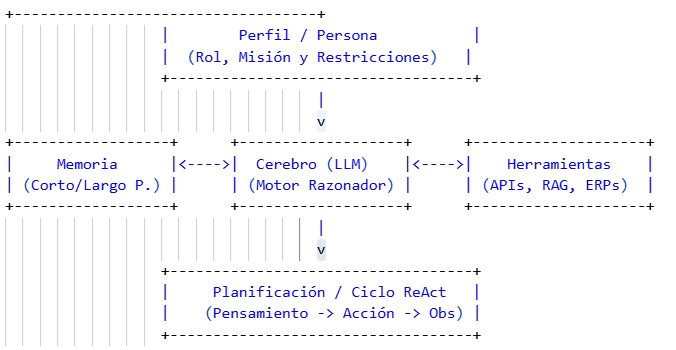

### 1. Motor de Razonamiento (LLM)

El "cerebro" encargado de procesar el lenguaje natural, comprender la intención del usuario y determinar las acciones a seguir. No contiene la verdad absoluta de la empresa, sino la capacidad lógica para operar sobre los datos.

### 2. Perfil de Rol y Contexto (System Prompt / Goal)

Establece las reglas de comportamiento, límites éticos, formato de salida y el objetivo de negocio. En logística, esto evita que un agente de atención interna modifique estados de despacho sin autorización o entregue datos protegidos por la Ley de Protección de la Vida Privada (Ley 19.628).

### 3. Sistema de Memoria

- **Memoria de Corto Plazo:** Mantiene el hilo de la conversación actual (Context Window).
- **Memoria de Largo Plazo:** Almacena historial de interacciones previas y conocimiento factual extraído mediante vectores de búsqueda.

### 4. Herramientas (*Tools*)

Conexiones deterministicas hacia sistemas externos. Un LLM no puede saber el estado real de un camión en la Ruta 68 a menos que ejecute una consulta a una API de rastreo GPS o a una base de datos PostgreSQL de la empresa.

### 5. Ciclo de Planificación (*ReAct: Reason + Act*)

El paradigma dominante donde el agente alterna entre tres etapas clave:

- **Thought (Pensamiento):** Analiza qué necesita para responder.
- **Action (Acción):** Selecciona una herramienta y la ejecuta con parámetros concretos.
- **Observation (Observación):** Evalúa la respuesta de la herramienta para decidir si requiere otra acción o si puede redactar la respuesta final.

## Comparativa Inicial: CrewAI vs. LangChain

| **Criterio**              | **CrewAI**                                                             | **LangChain**                                                                      |
| ------------------------- | ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Abstracción Principal** | Basado en Roles y Equipos de trabajo (*Agents*, *Tasks*, *Crew*).      | Basado en Cadenas y Grafos de Flujo (*Chains*, *Tools*, *LangGraph*).              |
| **Curva de Aprendizaje**  | Rápida, semántica e intuitiva para modelar flujos de trabajo humanos.  | Moderada/Alta, requiere mayor control explícito de código.                         |
| **Casos de Uso Ideales**  | Colaboración multi-agente, delegación de tareas y flujos cualitativos. | Control determinista paso a paso, orquestación fina de pipelines y RAGs complejos. |

## Implementación Práctica: Agente de Consulta Logística

En este módulo construiremos la estructura de un agente basado en el patrón **ReAct** utilizando Python limpio, estructurado mediante `Pydantic` y `LangChain`, para simular el procesamiento de una solicitud sobre una Guía de Despacho.

In [1]:
!pip install -qU langchain-google-genai langchain pydantic

In [12]:
# =====================================================================
# MÓDULO 1 FINAL - AGENTE DE CONSULTA LOGÍSTICA
# =====================================================================

import os
from typing import Dict, Any, List, Union
from google.colab import userdata

# Importamos los componentes de LangChain Core y Google GenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage


# =====================================================================
# 1. CONFIGURACIÓN DEL ENTORNO Y CREDENCIALES
# =====================================================================

def inicializar_entorno_google() -> bool:
    """Extrae la clave API desde los secretos de Colab y la configura

    en las variables de entorno del sistema operativo virtual.
    """
    try:
        # Recuperamos la clave almacenada en los Secretos de Colab (icono de llave)
        api_key_google = userdata.get('GOOGLE_API_KEY')

        # Inyectamos la variable en el SO para que la librería la detecte automáticamente
        os.environ["GOOGLE_API_KEY"] = api_key_google
        print("✅ Credenciales de Google API configuradas correctamente.")
        return True

    except Exception as error_credenciales:
        print(f"❌ Error al cargar credenciales: {error_credenciales}")
        print("Asegúrate de configurar 'GOOGLE_API_KEY' en la pestaña Secretos de Colab.")
        return False


# =====================================================================
# 2. DEFINICIÓN DE HERRAMIENTAS (TOOLS) CON TIPADO RIGUROSO
# =====================================================================

@tool
def consultar_estado_guia(numero_guia: str) -> str:
    """Consulta el estado actual de una guía de despacho en el sistema ERP logístico.

    Usa esta herramienta cuando la solicitud mencione un código de guía de despacho
    (por ejemplo: GD-2026-88) para obtener su origen, destino, estado y fecha de llegada.
    """
    # Simulamos la base de datos relacional del ERP logístico de la empresa
    base_datos_erp: Dict[str, Dict[str, str]] = {
        "GD-2026-88": {
            "estado": "En Tránsito",
            "origen": "Centro de Distribución Pudahuel",
            "destino": "Bodega Concepción",
            "fecha_estimada": "2026-09-30"
        },
        "GD-2026-89": {
            "estado": "Entregado",
            "origen": "San Bernardo",
            "destino": "Valparaíso",
            "fecha_estimada": "2026-09-27"
        }
    }

    # Limpiamos espacios e ignoramos diferencias entre mayúsculas y minúsculas
    guia_limpia = numero_guia.strip().upper()

    # Búsqueda directa en los registros del ERP
    if guia_limpia in base_datos_erp:
        datos = base_datos_erp[guia_limpia]
        return (
            f"Guía {guia_limpia}: Estado: {datos['estado']} | "
            f"Origen: {datos['origen']} | Destino: {datos['destino']} | "
            f"Llegada estimada: {datos['fecha_estimada']}"
        )

    return f"Error: La guía '{guia_limpia}' no existe en el sistema ERP."


# Mapeo de herramientas para su ejecución dinámica
herramientas_logistica = [consultar_estado_guia]
mapa_herramientas = {t.name: t for t in herramientas_logistica}


# =====================================================================
# 3. FUNCIÓN DE EXTRACCIÓN Y FORMATEO DE TEXTO
# =====================================================================

def extraer_texto_limpio(contenido_raw: Union[str, List[Any]]) -> str:
    """Procesa el contenido devuelto por Gemini y extrae únicamente el texto legible."""
    if isinstance(contenido_raw, str):
        return contenido_raw.strip()

    if isinstance(contenido_raw, list):
        textos = []
        for elemento in contenido_raw:
            if isinstance(elemento, dict) and "text" in elemento:
                textos.append(elemento["text"])
            elif isinstance(elemento, str):
                textos.append(elemento)
        return "\n".join(textos).strip()

    return str(contenido_raw).strip()


# =====================================================================
# 4. ORQUESTACIÓN DEL AGENTE Y CICLO COMPLETO DE EJECUCIÓN
# =====================================================================

def ejecutar_agente_logistico(consulta_usuario: str) -> None:
    """Inicializa Gemini 3.5 Flash Lite, ejecuta la herramienta ERP y entrega la respuesta final."""

    # 1. Validar la configuración de credenciales
    if not inicializar_entorno_google():
        return

    # 2. Instanciar el modelo con temperatura 0.0 para maximizar la precisión
    llm_gemini = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        #temperature=0.0
    )

    # 3. Vincular las herramientas de forma nativa a la instancia de Gemini
    llm_con_herramientas = llm_gemini.bind_tools(herramientas_logistica)

    # 4. Definir el System Message con las instrucciones del rol logístico
    mensaje_sistema = SystemMessage(
        content=(
            "Eres un asistente virtual especializado en la gestión logística interna de la empresa. "
            "Tu objetivo es responder consultas sobre envíos y guías de despacho. "
            "Para responder preguntas sobre guías específicas, SIEMPRE debes invocar la herramienta "
            "de consulta al ERP antes de entregar una respuesta final."
        )
    )

    # 5. Inicializar la lista de mensajes de la conversación
    mensajes = [
        mensaje_sistema,
        HumanMessage(content=consulta_usuario)
    ]

    print(f"\n--- PROCESANDO SOLICITUD LOGÍSTICA ---")
    print(f"Consulta: {consulta_usuario}\n")

    # Paso 1: Primera invocación al modelo
    respuesta_paso_1 = llm_con_herramientas.invoke(mensajes)
    mensajes.append(respuesta_paso_1)

    # Paso 2: Verificar si Gemini solicitó ejecutar herramientas
    if respuesta_paso_1.tool_calls:
        for llamada in respuesta_paso_1.tool_calls:
            nombre_funcion = llamada["name"]
            argumentos = llamada["args"]
            id_llamada = llamada["id"]

            print(f"⚙️ [Ejecutando Herramienta ERP]: {nombre_funcion}({argumentos})")

            # Ejecutamos la función Python correspondiente
            funcion_python = mapa_herramientas[nombre_funcion]
            resultado_observacion = funcion_python.invoke(argumentos)

            print(f"👁️ [Observación del ERP]: {resultado_observacion}\n")

            # Registramos el resultado técnico dentro del historial como ToolMessage
            mensajes.append(ToolMessage(
                content=str(resultado_observacion),
                tool_call_id=id_llamada
            ))

        # Paso 3: Segunda invocación para redactar la respuesta estructurada final
        respuesta_paso_2 = llm_con_herramientas.invoke(mensajes)
        respuesta_final_limpia = extraer_texto_limpio(respuesta_paso_2.content)
    else:
        respuesta_final_limpia = extraer_texto_limpio(respuesta_paso_1.content)

    print("--- RESPUESTA FINAL ENTREGADA AL USUARIO ---")
    print(respuesta_final_limpia)


# =====================================================================
# EJECUCIÓN DEL MÓDULO
# =====================================================================
if __name__ == "__main__":
    solicitud = "¿Cuál es el estado actual de la guía de despacho GD-2026-88 y cuándo debería llegar a su destino?"
    ejecutar_agente_logistico(solicitud)

✅ Credenciales de Google API configuradas correctamente.

--- PROCESANDO SOLICITUD LOGÍSTICA ---
Consulta: ¿Cuál es el estado actual de la guía de despacho GD-2026-88 y cuándo debería llegar a su destino?

⚙️ [Ejecutando Herramienta ERP]: consultar_estado_guia({'numero_guia': 'GD-2026-88'})
👁️ [Observación del ERP]: Guía GD-2026-88: Estado: En Tránsito | Origen: Centro de Distribución Pudahuel | Destino: Bodega Concepción | Llegada estimada: 2026-09-30

--- RESPUESTA FINAL ENTREGADA AL USUARIO ---
El estado actual de la guía de despacho **GD-2026-88** es **En Tránsito**. 

* **Origen:** Centro de Distribución Pudahuel
* **Destino:** Bodega Concepción
* **Fecha estimada de llegada:** 30 de septiembre de 2026


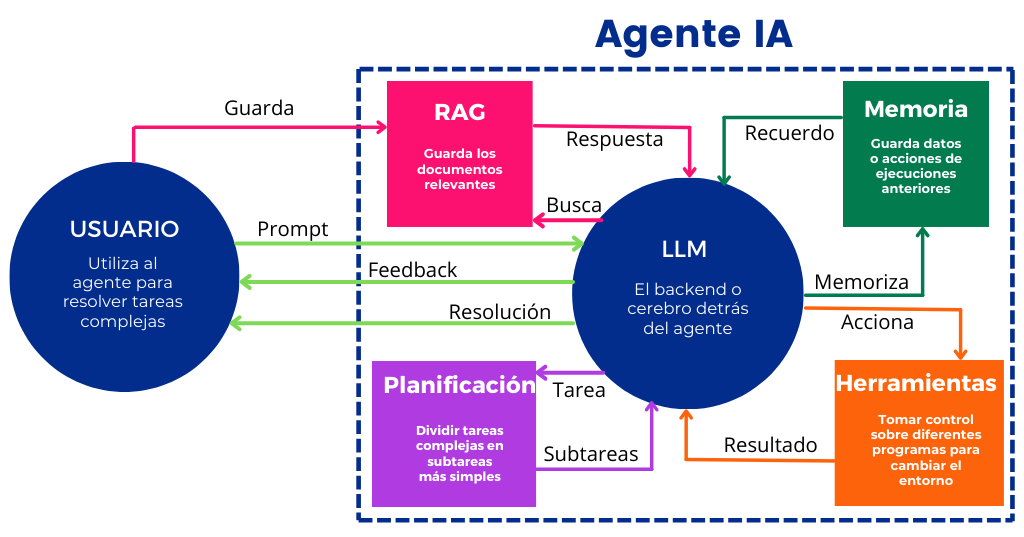

# 2. Comparativa de Paradigmas: Filosofía CrewAI vs. LangChain / LangGraph

## 1. Introducción al Dilema Arquitectónico en Inteligencia Artificial

Cuando una empresa del sector logístico en Chile decide automatizar la gestión de solicitudes, guías de despacho y consultas documentales mediante **agentes inteligentes**, el equipo de ingeniería se enfrenta a una decisión fundamental de arquitectura: **¿Cómo debemos estructurar la colaboración y el control del sistema?**

No existe un framework único universal. La elección entre un enfoque basado en **colaboración orientada a roles (CrewAI)** o un enfoque basado en **grafos de estado deterministas (LangChain / LangGraph)** determina no solo la velocidad de desarrollo inicial, sino también la mantenibilidad, la capacidad de auditoría, la latencia y la confiabilidad del sistema ante fallos o variaciones en los datos corporativos.

## 2. Filosofía CrewAI: Colaboración Antropomórfica Orientada a Roles

### Principios Fundamentales

CrewAI modela los sistemas multi-agente imitando la estructura de un equipo de trabajo humano. En este paradigma, cada agente se define mediante tres pilares sociológicos:

- **Role (Rol):** La especialidad o cargo del agente (ej. "Analista de Guías de Despacho", "Auditor de Cumplimiento").
- **Goal (Objetivo):** La meta concreta que el agente intenta maximizar.
- **Backstory (Trasfondo):** El contexto, experiencia y estilo cognitivo que condiciona las decisiones del LLM.

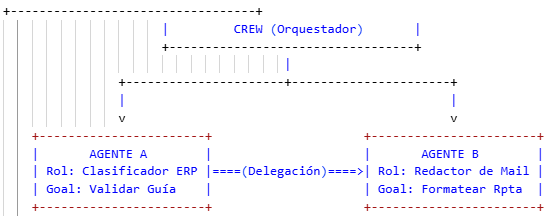

### Ventajas de CrewAI

1. **Alta Abstracción:** Permite prototipar rápidamente flujos complejos delegando la orquestación interna al propio LLM.
2. **Autonomía y Delegación:** Los agentes pueden delegarse tareas entre sí de forma dinámica si detectan que no poseen las herramientas necesarias para completar un objetivo.
3. **Expresividad Semántica:** Muy adecuado para procesos cualitativos, generación de contenido, síntesis documental y análisis exploratorio.

### Limitaciones en Entornos Corporativos

- **Menor Determinismo:** Al confiar la orquestación a decisiones del LLM, el flujo exacto de ejecución puede variar entre solicitudes idénticas.
- **Riesgo de Bucles Infinitos:** Sin controles explícitos, los agentes pueden quedar atascados delegándose tareas iterativamente.
- **Consumo Elevado de Tokens:** La sobrecarga de prompts que incluyen historias de fondo, roles y conversaciones intermedias incrementa los costos y la latencia.

## 3. Filosofía LangChain / LangGraph: Control Fino y Grafos de Estado Deterministas

### Principios Fundamentales

LangChain y su extensión de orquestación avanzadas, **LangGraph**, abandonan la metáfora del "equipo humano" y adoptan la teoría de sistemas: el proceso se modela como un **Grafo Dirigido con Estado (Stateful Directed Graph)**.

- **State (Estado):** Una estructura de datos centralizada (ej. un objeto Pydantic o un diccionario) que evoluciona a medida que pasa por el sistema.
- **Nodes (Nodos):** Funciones puras o llamadas a LLMs que reciben el estado actual, realizan una transformación o acción, y retornan un estado actualizado.
- **Edges (Aristas / Condicionales):** Reglas deterministas escritas en código Python que deciden el camino hacia el siguiente nodo según el contenido del estado.

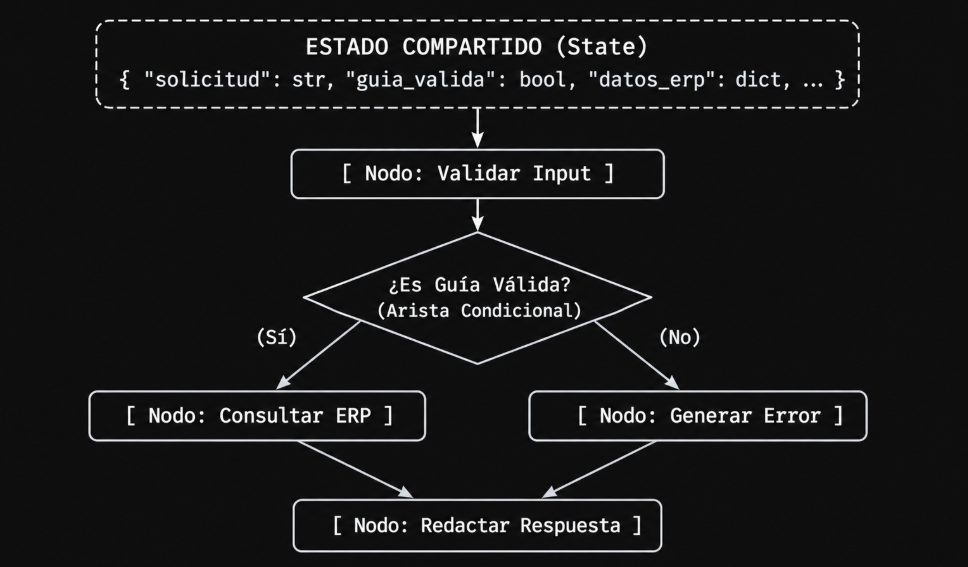

### Ventajas de LangGraph

1. **Determinismo Operacional:** Las rutas críticas, bifurcaciones de seguridad y validaciones de datos se controlan medianamente código explícito (`if/else`), no mediante especulaciones del modelo.
2. **Trazabilidad Completa:** Permite auditar el estado exacto en cada paso de ejecución, facilitando la detección de alucinaciones y la corrección de errores.
3. **Ciclos de Retroalimentación Flexibles:** Permite definir bucles de reintento controlados y pausar la ejecución para validación humana (*Human-in-the-loop*).

### Limitaciones

- **Mayor Complejidad de Desarrollo:** Requiere diseñar de antemano el diagrama de estados y escribir más código boilerplate.
- **Curva de Aprendizaje:** Exige comprender conceptos de programación funcional, estados inmutables y manejo de grafos dirigidos.

## 4. Matriz Comparativa para Toma de Decisiones en Logística

| **Dimensión**                | **Enfoque Orientado a Roles (Estilo CrewAI)**                | **Enfoque Orientado a Grafos (Estilo LangGraph)**              |
| ---------------------------- | ------------------------------------------------------------ | -------------------------------------------------------------- |
| **Mecanismo de Control**     | Prompts de rol y delegación semántica.                       | Grafos explicito en Python y transiciones de estado.           |
| **Garantía de Ejecución**    | Probabilística (depende del comportamiento del LLM).         | Determinista (las aristas fuerzan el camino correcto).         |
| **Facilidad de Prototipado** | **Muy Alta:** Pocas líneas de código configurativo.          | **Moderada:** Requiere definir esquemas de estado y nodos.     |
| **Seguridad e Integridad**   | Riesgo moderado si el agente interpreta mal su rol.          | **Máxima:** Permite bloquear entradas inválidas antes del LLM. |
| **Caso de Uso Ideal**        | Brainstorming, síntesis de reportes, análisis multiobjetivo. | Integración ERP, facturación, flujos auditables, RAG estricto. |

## Implementación Práctica: Comparativa de Paradigmas

En este ejercicio implementaremos dos motores para resolver el mismo problema logístico (procesar una solicitud de cambio de dirección de despacho):

1. **Paradigma A (Estilo CrewAI / Orientado a Roles):** Simulación de un pipeline secuencial de agentes especializados mediante roles y promps dedicados.
2. **Paradigma B (Estilo LangGraph / Orientado a Estados):** Un flujo de estado determinista estructurado con validaciones en código Python antes de invocar la LLM.

In [14]:
# =====================================================================
# MÓDULO 2 - COMPARATIVA DE PARADIGMAS: CREWAI VS LANGGRAPH
# =====================================================================

from typing import Optional
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

# Instanciamos el modelo SIN el parámetro temperature para evitar el UserWarning
llm_evaluador = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)


# =====================================================================
# PARADIGMA A: ENFOQUE ORIENTADO A ROLES Y DELEGACIÓN (ESTILO CREWAI)
# =====================================================================

class AgenteRol:
    def __init__(self, nombre: str, rol: str, objetivo: str, trasfondo: str):
        self.nombre = nombre
        self.rol = rol
        self.objetivo = objetivo
        self.trasfondo = trasfondo

    def ejecutar_tarea(self, entrada_contexto: str, llm: ChatGoogleGenerativeAI) -> str:
        prompt_sistema = (
            f"Eres {self.nombre}, tu rol es {self.rol}.\n"
            f"Tu objetivo principal es: {self.objetivo}.\n"
            f"Trasfondo: {self.trasfondo}.\n"
            "Responde estrictamente según los límites de tu rol."
        )

        mensajes = [
            SystemMessage(content=prompt_sistema),
            HumanMessage(content=f"Tarea recibida:\n{entrada_contexto}")
        ]

        respuesta = llm.invoke(mensajes)
        # Usamos extraer_texto_limpio (del Módulo 1) en lugar de str() directo
        return extraer_texto_limpio(respuesta.content)


def ejecutar_flujo_orientado_a_roles(solicitud_usuario: str) -> None:
    print("\n" + "="*70)
    print("PARADIGMA A: EJECUCIÓN ORIENTADA A ROLES (ESTILO CREWAI)")
    print("="*70)

    agente_auditor = AgenteRol(
        nombre="Agente Auditor de Despachos",
        rol="Auditor de Seguridad Operacional",
        objetivo="Determinar si una solicitud de cambio de dirección es legítima y segura",
        trasfondo="Experto en prevención de fraudes en transporte de carga corporativa en Chile."
    )

    agente_redactor = AgenteRol(
        nombre="Agente de Servicio al Cliente",
        rol="Redactor Administrativo",
        objetivo="Generar una respuesta formal y clara para el cliente interno",
        trasfondo="Especialista en comunicación corporativa y normas de atención logística."
    )

    print("\n🤖 [Paso 1 - Agente Auditor]: Analizando solicitud...")
    dictamen_seguridad = agente_auditor.ejecutar_tarea(solicitud_usuario, llm_evaluador)
    print(f"Resultado del Análisis:\n{dictamen_seguridad}\n")

    contexto_para_redactor = (
        f"Solicitud Original del Cliente: {solicitud_usuario}\n"
        f"Dictamen del Auditor de Seguridad: {dictamen_seguridad}"
    )

    print("🤖 [Paso 2 - Agente Redactor]: Elaborando respuesta final...")
    respuesta_final = agente_redactor.ejecutar_tarea(contexto_para_redactor, llm_evaluador)
    print(f"Respuesta Final Entregada:\n{respuesta_final}")


# =====================================================================
# PARADIGMA B: ENFOQUE ORIENTADO A ESTADOS Y GRAFOS (ESTILO LANGGRAPH)
# =====================================================================

class EstadoSolicitudLogistica(BaseModel):
    solicitud_raw: str = Field(..., description="Texto original enviado por el usuario")
    codigo_guia: Optional[str] = Field(None, description="Identificador extraído de la guía")
    es_solicitud_valida: bool = Field(False, description="Flag de validación determinista")
    motivo_rechazo: Optional[str] = Field(None, description="Causa del rechazo si aplica")
    respuesta_generada: Optional[str] = Field(None, description="Mensaje final sintetizado")


def nodo_extraccion_y_validacion_codigo(estado: EstadoSolicitudLogistica) -> EstadoSolicitudLogistica:
    print("\n⚙️ [Nodo 1 - Código Python]: Extrayendo y validando identificadores...")

    texto = estado.solicitud_raw.upper()
    if "GD-" in texto:
        inicio = texto.find("GD-")
        codigo_extraido = texto[inicio:inicio+10]
        estado.codigo_guia = codigo_extraido
        estado.es_solicitud_valida = True
        print(f"✓ Código identificado: {codigo_extraido}")
    else:
        estado.es_solicitud_valida = False
        estado.motivo_rechazo = "No se proporcionó un código de guía válido (Ej: GD-2026-88)."
        print("❌ Fallo de validación: Código de guía no encontrado.")

    return estado


def nodo_redaccion_inteligente(
    estado: EstadoSolicitudLogistica,
    llm: ChatGoogleGenerativeAI
) -> EstadoSolicitudLogistica:
    print("⚙️ [Nodo 2 - LLM Gemini]: Generando respuesta basada en el estado verificado...")

    prompt = (
        f"La solicitud para la guía {estado.codigo_guia} fue validada correctamente por el sistema. "
        f"Redacta una confirmación breve y profesional para el área de operaciones confirmando "
        f"que la solicitud '{estado.solicitud_raw}' ha ingresado a la cola de procesamiento."
    )

    respuesta = llm.invoke([HumanMessage(content=prompt)])
    # Usamos extraer_texto_limpio (del Módulo 1) en lugar de str() directo
    estado.respuesta_generada = extraer_texto_limpio(respuesta.content)
    return estado


def ejecutar_flujo_orientado_a_estados(solicitud_usuario: str) -> None:
    print("\n" + "="*70)
    print("PARADIGMA B: EJECUCIÓN ORIENTADA A ESTADOS (ESTILO LANGGRAPH)")
    print("="*70)

    estado_actual = EstadoSolicitudLogistica(solicitud_raw=solicitud_usuario)
    estado_actual = nodo_extraccion_y_validacion_codigo(estado_actual)

    if estado_actual.es_solicitud_valida:
        estado_actual = nodo_redaccion_inteligente(estado_actual, llm_evaluador)
        print(f"\nRespuesta Final Entregada:\n{estado_actual.respuesta_generada}")
    else:
        estado_actual.respuesta_generada = f"Solicitud Rechazada: {estado_actual.motivo_rechazo}"
        print(f"\nRespuesta de Control Directa:\n{estado_actual.respuesta_generada}")


# =====================================================================
# EJECUCIÓN COMPARATIVA DE AMBOS PARADIGMAS
# =====================================================================
if __name__ == "__main__":
    solicitud_valida = "Hola, necesito cambiar la dirección de entrega de la guía GD-2026-88 a Av. Viña del Mar 450."
    print("--- EVALUANDO SOLICITUD VÁLIDA ---")
    ejecutar_flujo_orientado_a_roles(solicitud_valida)
    ejecutar_flujo_orientado_a_estados(solicitud_valida)

    solicitud_invalida = "Por favor cambien la dirección de mi pedido urgente para mañana mismo."
    print("\n\n--- EVALUANDO SOLICITUD INVÁLIDA (SIN GUÍA) ---")
    ejecutar_flujo_orientado_a_roles(solicitud_invalida)
    ejecutar_flujo_orientado_a_estados(solicitud_invalida)

--- EVALUANDO SOLICITUD VÁLIDA ---

PARADIGMA A: EJECUCIÓN ORIENTADA A ROLES (ESTILO CREWAI)

🤖 [Paso 1 - Agente Auditor]: Analizando solicitud...
Resultado del Análisis:
**PROTOCOLO DE AUDITORÍA DE SEGURIDAD OPERACIONAL**
**Agente Auditor de Despachos – Prevención de Fraudes (Chile)**

Solicitud recibida. Como Auditor de Seguridad Operacional, **NO** autorizo el cambio de dirección de entrega para la guía **GD-2026-88** bajo ninguna circunstancia en este momento. 

En el transporte de carga corporativa en Chile, la modificación de rutas y destinos de última hora es uno de los vectores de fraude (secuestro de cargas, *portonazos* virtuales, desvíos no autorizados y suplantación de identidad) más críticos. 

Para proceder con cualquier análisis de viabilidad, se requiere ejecutar de manera **estricta y obligatoria** el siguiente Protocolo de Verificación de Fraude Corporativo:

1. **Validación de Identidad del Solicitante:**
   * Nombre completo, RUT y cargo de la persona que solicita e

# 3. Diseño de Agentes Orientados a Roles y Tareas en CrewAI

## 1. Arquitectura de CrewAI: Los 4 Pilares Fundamentales

CrewAI es un framework diseñado para orquestar agentes autónomos de IA que colaboran imitando la estructura de una organización humana. Su diseño se sostiene sobre cuatro pilares esenciales:

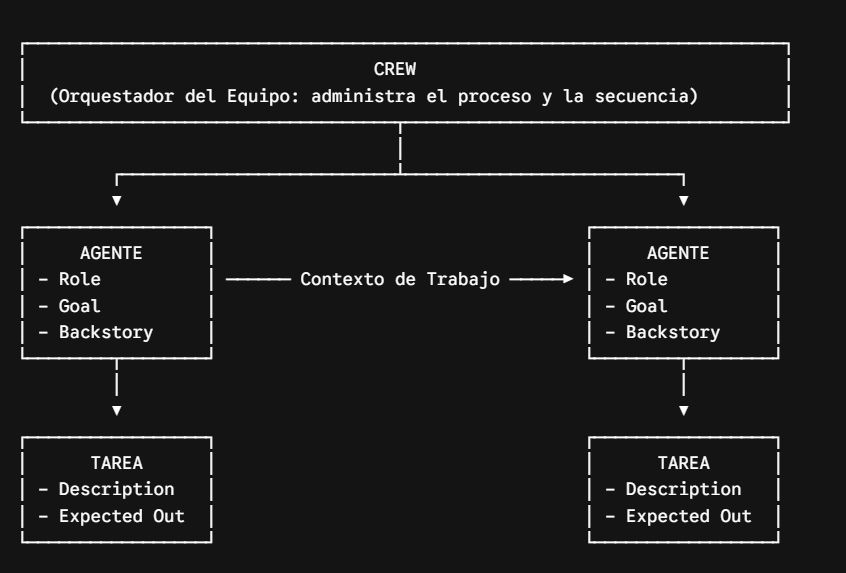

1. **Agente (`Agent`):** Unidad de ejecución autónoma dotada de una personalidad profesional, objetivos específicos, contexto histórico (*backstory*) y acceso opcional a herramientas.
2. **Tarea (`Task`):** Unidad de trabajo concreta asignada a un agente. Define exactamente qué se debe hacer (*description*) y cómo debe ser el resultado esperado (*expected_output*).
3. **Equipo (`Crew`):** El entorno contenedor que agrupa a los agentes y las tareas, gestionando el flujo de información entre ellos.
4. **Proceso (`Process`):** La estrategia de ejecución del equipo:
   - **Secuencial (`Process.sequential`):** Las tareas se ejecutan en orden lineal, pasando la salida de una tarea como contexto a la siguiente.
   - **Jerárquico (`Process.hierarchical`):** Un agente "Manager" delega y revisa las tareas ejecutadas por agentes subordinados.

## 2. Anatomía de un Agente Antropomórfico

A diferencia de un prompt tradicional donde solo se pide una tarea, CrewAI exige **antropomorfizar** la LLM mediante tres atributos clave:

- **`role` (Rol):** Define la posición funcional del agente dentro de la empresa.
  - *Ejemplo:* `"Analista de Riesgos Logísticos"`
- **`goal` (Objetivo):** Especifica la métrica de éxito o el propósito fundamental que el agente busca maximizar.
  - *Ejemplo:* `"Identificar inconsistencias y prevenir fraudes en las modificaciones de rutas de transporte."`
- **`backstory` (Trasfondo / Historia de origen):** Aporta experiencia, sesgo profesional y tono cognitivo. La LLM utiliza este contexto para razonar como un verdadero especialista con años de trayectoria.
  - *Ejemplo:* `"Llevas 15 años auditando cadenas de suministro corporativas en Chile. Eres metódico, desconfiado de las solicitudes de última hora y extremadamente riguroso con los protocolos de seguridad."`

## 3. Definición de Tareas y Salidas Esperadas (`Expected Output`)

Una falla común en sistemas multi-agente es definir tareas ambiguas. CrewAI resuelve esto obligando a estructurar las tareas con dos componentes obligatorios:

| **Componente**        | **Función**                                                                      | **Ejemplo Práctico**                                                                                                                                               |
| --------------------- | -------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`description`**     | Explica detalladamente qué debe hacer el agente y qué variables debe considerar. | `"Analiza la solicitud {solicitud} y verifica si la guía {guia} cumple con las normas de seguridad para un cambio de domicilio."`                                  |
| **`expected_output`** | Modela el formato exacto, estructura y estilo del entregable final.              | `"Un dictamen de seguridad de máximo 3 párrafos especificando: 1. Nivel de riesgo (Alto/Medio/Bajo), 2. Justificación técnica, 3. Decisión (Aprobado/Rechazado)."` |

## 4. Código de Implementación Práctica de la Seccion 3

A continuación se implementa el diseño completo de un **Equipo de Gestión Logística (Crew)** compuesto por 3 agentes especializados que procesan secuencialmente una solicitud compleja.



In [15]:
# =====================================================================
# MÓDULO 3 - DISEÑO DE AGENTES, TAREAS Y CREW (SISTEMA COMPLETO)
# =====================================================================

from typing import List, Dict, Any
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage


# =====================================================================
# 1. INICIALIZACIÓN DEL MODELO BASE
# =====================================================================

# Instanciamos Gemini 3.5 Flash Lite
llm_crew = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)


# =====================================================================
# 2. DEFINICIÓN DE ESTRUCTURAS CORE DE CREWAI
# =====================================================================

class AgenteCrew:
    """Estructura que representa un Agente autónomo en CrewAI."""

    def __init__(self, role: str, goal: str, backstory: str):
        self.role = role
        self.goal = goal
        self.backstory = backstory

    def generar_prompt_sistema(self) -> str:
        """Construye el prompt antropomórfico del agente."""
        return (
            f"Eres {self.role}.\n"
            f"Tu objetivo principal es: {self.goal}.\n"
            f"Trasfondo profesional: {self.backstory}.\n\n"
            "Instrucciones operativas: Cumple tu tarea con el máximo rigor profesional "
            "apegándote exclusivamente a tu rol y objetivo asignado."
        )


class TareaCrew:
    """Estructura que representa una Tarea específica dentro del flujo."""

    def __init__(self, description: str, expected_output: str, agente: AgenteCrew):
        self.description = description
        self.expected_output = expected_output
        self.agente = agente
        self.resultado: str = ""

    def ejecutar(self, contexto_previo: str, llm: ChatGoogleGenerativeAI) -> str:
        """Ejecuta la tarea usando el LLM y el contexto acumulado de tareas anteriores."""
        prompt_sistema = self.agente.generar_prompt_sistema()

        prompt_usuario = (
            f"=== DESCRIPCIÓN DE LA TAREA ===\n{self.description}\n\n"
            f"=== FORMATO DE SALIDA ESPERADO ===\n{self.expected_output}\n\n"
        )

        if contexto_previo:
            prompt_usuario += f"=== CONTEXTO ACUMULADO DE TAREAS ANTERIORES ===\n{contexto_previo}\n\n"

        mensajes = [
            SystemMessage(content=prompt_sistema),
            HumanMessage(content=prompt_usuario)
        ]

        respuesta = llm.invoke(mensajes)
        # Limpiamos el contenido devuelto utilizando la función del Módulo 1
        self.resultado = extraer_texto_limpio(respuesta.content)
        return self.resultado


class EquipoCrew:
    """Orquestador que gestiona la ejecución secuencial de Agentes y Tareas."""

    def __init__(self, agentes: List[AgenteCrew], tareas: List[TareaCrew]):
        self.agentes = agentes
        self.tareas = tareas

    def kickoff(self, inputs: Dict[str, Any], llm: ChatGoogleGenerativeAI) -> str:
        """Inicia el proceso secuencial (Process.sequential) pasando el contexto."""
        print("\n" + "="*70)
        print("🚀 INICIANDO EJECUCIÓN DEL EQUIPO LOGÍSTICO (CREW KICKOFF)")
        print("="*70)

        contexto_acumulado = f"Datos de entrada iniciales: {inputs}\n\n"

        for idx, tarea in enumerate(self.tareas, 1):
            print(f"\n📋 [Ejecutando Tarea {idx}/{len(self.tareas)}] -> Asignada a: {tarea.agente.role}")

            # Formateamos la descripción con los inputs iniciales
            tarea.description = tarea.description.format(**inputs)

            # Ejecutamos la tarea pasando el historial acumulado
            resultado_tarea = tarea.ejecutar(contexto_acumulado, llm)

            print(f"✅ Tarea {idx} Finalizada.")
            print(f"--- Resultado Parcial ({tarea.agente.role}) ---")
            print(resultado_tarea)
            print("-" * 50)

            # Acumulamos la salida para el siguiente agente de la cadena
            contexto_acumulado += (
                f"\n--- SALIDA DE LA TAREA {idx} ({tarea.agente.role}) ---\n"
                f"{resultado_tarea}\n\n"
            )

        return resultado_tarea


# =====================================================================
# 3. CONFIGURACIÓN DEL EQUIPO LOGÍSTICO (AGENTES Y TAREAS)
# =====================================================================

def crear_equipo_logistico() -> EquipoCrew:
    """Instancia los agentes, define sus tareas y crea la orquestación del Equipo."""

    # AGENTE 1: Auditor de Seguridad Operacional
    agente_auditor = AgenteCrew(
        role="Auditor de Seguridad Operacional Logística",
        goal="Evaluar el nivel de riesgo de solicitudes de cambio sobre guías de despacho.",
        backstory="Experto en prevención de fraudes y desvíos de carga corporativa en Chile. Analiza minuciosamente los cambios de destino."
    )

    # AGENTE 2: Planificador de Rutas ERP
    agente_planificador = AgenteCrew(
        role="Especialista en Planificación de Rutas ERP",
        goal="Verificar la factibilidad técnica y logística de re-enrutamiento de carga.",
        backstory="Ingeniero en transporte encargado de coordinar con los centros de distribución y camiones en tránsito."
    )

    # AGENTE 3: Redactor de Comunicaciones Internas
    agente_redactor = AgenteCrew(
        role="Oficial de Comunicaciones Logísticas",
        goal="Sintetizar los análisis técnicos en una resolución ejecutiva formal.",
        backstory="Especialista en redacción corporativa capacitado para comunicar decisiones complejas de forma clara y directa."
    )

    # TAREA 1: Evaluación de Riesgo
    tarea_evaluar_riesgo = TareaCrew(
        description="Analiza la solicitud de cambio de dirección para la guía {numero_guia} hacia la dirección '{nueva_direccion}'. Evalúa si existe riesgo de fraude.",
        expected_output="Dictamen de Seguridad indicando: Nivel de Riesgo (Bajo/Medio/Alto), Riesgos Detectados y Recomendación de Aprobación.",
        agente=agente_auditor
    )

    # TAREA 2: Análisis de Factibilidad
    tarea_factibilidad_ruta = TareaCrew(
        description="Revisa el dictamen del auditor y determina si la guía {numero_guia} puede ser re-enrutada técnicamente hacia {nueva_direccion}.",
        expected_output="Informe de Factibilidad con: Impacto en tiempo de entrega, costo operativo adicional y factibilidad (Sí/No).",
        agente=agente_planificador
    )

    # TAREA 3: Resolución Final
    tarea_resolucion_final = TareaCrew(
        description="Consolida el Dictamen de Seguridad y el Informe de Factibilidad en un memorándum de resolución oficial.",
        expected_output="Memorándum formal de resolución ejecutiva para la guía {numero_guia} listo para ser enviado a operaciones.",
        agente=agente_redactor
    )

    # Creación de la Crew con sus componentes
    equipo_logistica = EquipoCrew(
        agentes=[agente_auditor, agente_planificador, agente_redactor],
        tareas=[tarea_evaluar_riesgo, tarea_factibilidad_ruta, tarea_resolucion_final]
    )

    return equipo_logistica


# =====================================================================
# EJECUCIÓN DEL MÓDULO 3
# =====================================================================
if __name__ == "__main__":
    # Creamos el equipo logístico
    equipo = crear_equipo_logistico()

    # Parámetros de entrada de la solicitud
    datos_solicitud = {
        "numero_guia": "GD-2026-88",
        "nueva_direccion": "Av. Viña del Mar 450, Valparaíso"
    }

    # Ejecutamos el flujo secuencial
    resolucion_final = equipo.kickoff(datos_solicitud, llm_crew)

    print("\n" + "="*70)
    print("📢 ENTREGABLE FINAL DEL EQUIPO LOGÍSTICO")
    print("="*70)
    print(resolucion_final)


🚀 INICIANDO EJECUCIÓN DEL EQUIPO LOGÍSTICO (CREW KICKOFF)

📋 [Ejecutando Tarea 1/3] -> Asignada a: Auditor de Seguridad Operacional Logística
✅ Tarea 1 Finalizada.
--- Resultado Parcial (Auditor de Seguridad Operacional Logística) ---
**DICTAMEN DE SEGURIDAD OPERACIONAL LOGÍSTICA**

* **Guía de Despacho:** GD-2026-88
* **Dirección Solicitada:** Av. Viña del Mar 450, Valparaíso
* **Nivel de Riesgo:** ALTO

---

### **Riesgos Detectados:**
1. **Inconsistencia Geográfica y Toponímica:** La dirección indicada ("Av. Viña del Mar") corresponde al nombre de una arteria o comuna principal de la ciudad vecina (Viña del Mar), lo que genera una ambigüedad crítica en la zonificación urbana y postal dentro de la comuna de Valparaíso, aumentando drásticamente la probabilidad de entregas erróneas o simulación de entrega.
2. **Vulnerabilidad de Desvío de Carga:** Modificar el destino final de una guía de despacho hacia una zona interurbana o limítrofe sin validación presencial o confirmación por cana

# 4. Construcción de Grafos de Estado y Control Fino con LangChain / LangGraph

## 1. Fundamentos Arquitectónicos: El Paradigma del Control Fino

Mientras que los frameworks orientados a roles (como CrewAI) abstraen la complejidad operativa detrás de interacciones sociomórficas, **LangGraph** opera en un nivel de abstracción inferior y fundamental. Proporciona **control fino** (fine-grained control) sobre el ciclo de vida de la inferencia, permitiendo a los ingenieros diseñar topologías deterministas de ejecución.

El control fino se materializa al separar estrictamente la **Lógica de Inferencia** (ejecutada mediante los *Runnables* de LangChain en los Nodos) de la **Lógica de Control de Flujo** (definida en las Aristas del Grafo mediante código Python puro).

Esta separación permite construir **Grafos Cíclicos** —esenciales para la iteración algorítmica y los patrones de *Reflexión* (Actor-Crítico)—, superando las limitaciones de los Grafos Acíclicos Dirigidos (DAGs) y las cadenas secuenciales (Pipelines).

## 2. Los 4 Mecanismos de Control Avanzado

Para ejercer este control exhaustivo, la arquitectura se sustenta en cuatro mecanismos matemáticos y estructurales:

### 2.1 El Estado (State) y los Reductores (Reducers)

El Grafo posee un estado global (una estructura estática). Sin embargo, el *control fino* requiere definir exactamente **cómo** muta ese estado. Las bibliotecas de grafos utilizan "Reductores".

- **Reemplazo (Overwrite):** Si un nodo devuelve `{"clave": "nuevo_valor"}`, el estado sobreescribe el valor anterior.
- **Agregación (Append):** Si un nodo devuelve un elemento para una lista (ej. el historial de mensajes), el reductor anexa el nuevo elemento sin destruir los anteriores, preservando la traza computacional.

### 2.2 Nodos (Nodes): Aislamiento de Capacidades

Cada nodo envuelve una función específica, aislando las llamadas al motor inferencial de LangChain o la ejecución de herramientas (APIs, bases de datos). Al ser modulares, un nodo puede fallar o interrumpirse sin corromper el Grafo entero.

### 2.3 Aristas Condicionales (Conditional Edges): Enrutamiento Cíclico

La verdadera potencia del control fino radica en la capacidad de evaluar el Estado en $t$ y bifurcar la ejecución en $t+1$, permitiendo **retrocesos (loops)**. Si una salida no cumple con un umbral de calidad, una arista condicional puede devolver el flujo al nodo generador, inyectando el error específico en el Estado para forzar una corrección.

### 2.4 Checkpoints y Memoria Persistente

Al guardar instantáneas (snapshots) del Estado después de cada transición, el ingeniero adquiere control temporal sobre el flujo:

- **Interrupción determinista:** Pausar la ejecución antes de invocar una herramienta crítica para requerir validación asíncrona (*Human-In-The-Loop*).
- **Reanudación (*Time-Travel*):** Retroceder a un estado previo, modificar manualmente una variable del grafo, y reejecutar la computación desde ese nodo específico.

## 3. Implementación Práctica: Patrón Cíclico de Crítica y Revisión

A continuación, se demuestra el "Control Fino" mediante la implementación de un **Grafo Cíclico** utilizando LangChain para la estructuración de mensajes y LangGraph para la orquestación.

El sistema implementa un patrón **Actor-Crítico**: Un nodo redacta un documento y otro nodo actúa como un evaluador implacable. Si el evaluador detecta fallas, el flujo retorna cíclicamente al redactor, limitando el bucle a un máximo de 3 iteraciones para evitar ciclos infinitos.

In [19]:
# =====================================================================
# MÓDULO 4 - CONSTRUCCIÓN DE GRAFOS DE ESTADO Y CONTROL FINO
# =====================================================================

from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END

# Componentes de LangChain para la inferencia y estructuración
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage


# =====================================================================
# 1. DEFINICIÓN DEL ESTADO GLOBAL
# =====================================================================

class EstadoRedaccion(TypedDict):
    """
    Estructura de memoria que transita por el grafo.
    Almacena los artefactos intermedios y contadores para el control de ciclos.
    """
    tema: str
    borrador_actual: str
    feedback_critico: Optional[str]
    iteraciones: int
    aprobado: bool


# =====================================================================
# 2. DEFINICIÓN DE NODOS (ACTOR Y CRÍTICO)
# =====================================================================

def nodo_redactor(estado: EstadoRedaccion) -> dict:
    """
    Nodo Generador: Crea o corrige un borrador basándose en el estado.
    Si existe feedback previo, ajusta la generación.
    """
    iteracion_actual = estado.get("iteraciones", 0) + 1
    print(f"⚙️ [Ejecutando Nodo: REDACTOR] -> Iteración {iteracion_actual}")

    # Instanciación sin parámetro de temperatura
    llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

    prompt = f"Escribe un párrafo técnico breve sobre: {estado['tema']}."

    # Control Fino: Inyección de contexto condicional
    if estado.get("feedback_critico"):
        prompt += (
            f"\nBorrador anterior: {estado['borrador_actual']}\n"
            f"El revisor indicó el siguiente error: {estado['feedback_critico']}\n"
            "Corrige el borrador solucionando estrictamente ese error."
        )

    respuesta = llm.invoke([HumanMessage(content=prompt)])

    # Reutilización de la función global del Módulo 1 para garantizar un str limpio
    nuevo_borrador = extraer_texto_limpio(respuesta.content)

    # Mutación del estado: Actualiza el borrador e incrementa el contador
    return {
        "borrador_actual": nuevo_borrador,
        "iteraciones": iteracion_actual
    }


def nodo_evaluador(estado: EstadoRedaccion) -> dict:
    """
    Nodo Crítico: Evalúa el borrador y determina si cumple los estándares.
    Genera una directriz de corrección (feedback) en caso de rechazo.
    """
    print("🔍 [Ejecutando Nodo: EVALUADOR] -> Analizando métricas de calidad...")

    borrador = estado["borrador_actual"].lower()

    # Regla de negocio determinista para el control de flujo
    if "arquitectura" not in borrador:
        return {
            "aprobado": False,
            "feedback_critico": "Falta mencionar explícitamente el término 'arquitectura'."
        }

    return {
        "aprobado": True,
        "feedback_critico": None
    }


# =====================================================================
# 3. CONTROL DE FLUJO: ARISTAS CONDICIONALES
# =====================================================================

def enrutador_iterativo(estado: EstadoRedaccion) -> Literal["nodo_redactor", "END"]:
    """
    Arista Condicional (Routing).
    Evaluación de detención por éxito o límite de recursividad (circuit breaker).
    """
    if estado["aprobado"]:
        print("🟢 [Ruta Tomada] -> Aprobado, enviando a END.")
        return "END"

    if estado["iteraciones"] >= 3:
        print("🔴 [Ruta Tomada] -> Máximo de iteraciones alcanzado. Abortando a END.")
        return "END"

    print("🟡 [Ruta Tomada] -> Rechazado. Retornando al REDACTOR (Ciclo).")
    return "nodo_redactor"


# =====================================================================
# 4. COMPILACIÓN DE LA TOPOLOGÍA (GRAFO CÍCLICO)
# =====================================================================

def compilar_grafo_redaccion():
    builder = StateGraph(EstadoRedaccion)

    # Registro de nodos
    builder.add_node("nodo_redactor", nodo_redactor)
    builder.add_node("nodo_evaluador", nodo_evaluador)

    # Construcción de trayectorias
    builder.add_edge(START, "nodo_redactor")
    builder.add_edge("nodo_redactor", "nodo_evaluador")

    # Enrutamiento cíclico condicional
    builder.add_conditional_edges(
        "nodo_evaluador",
        enrutador_iterativo,
        {
            "nodo_redactor": "nodo_redactor",
            "END": END
        }
    )

    return builder.compile()


# =====================================================================
# 5. EJECUCIÓN DEL BUCLE DE CONTROL
# =====================================================================

if __name__ == "__main__":
    grafo = compilar_grafo_redaccion()

    print("\n" + "="*70)
    print("INICIO DE EJECUCIÓN: GRAFO CÍCLICO")
    print("="*70)

    estado_inicial = {
        "tema": "El diseño de sistemas multi-agentes en Python",
        "borrador_actual": "",
        "feedback_critico": None,
        "iteraciones": 0,
        "aprobado": False
    }

    resultado_final = grafo.invoke(estado_inicial)

    print("\n" + "="*70)
    print("ARTEFACTO RESULTANTE TRAS EL CONTROL FINO")
    print("="*70)
    print(f"Estado de Aprobación: {resultado_final['aprobado']}")
    print(f"Total Iteraciones Consumidas: {resultado_final['iteraciones']}")
    print(f"Texto Final:\n{resultado_final['borrador_actual']}")


INICIO DE EJECUCIÓN: GRAFO CÍCLICO
⚙️ [Ejecutando Nodo: REDACTOR] -> Iteración 1
🔍 [Ejecutando Nodo: EVALUADOR] -> Analizando métricas de calidad...
🟢 [Ruta Tomada] -> Aprobado, enviando a END.

ARTEFACTO RESULTANTE TRAS EL CONTROL FINO
Estado de Aprobación: True
Total Iteraciones Consumidas: 1
Texto Final:
El diseño de sistemas multi-agentes (MAS) en Python se estructura típicamente mediante arquitecturas orientadas a eventos y programación asíncrona, utilizando frameworks especializados como **Mesa** (para simulación basada en agentes), **SPADE** (basado en el estándar FIPA-ACL y tecnologías XMPP) o **AutoGen** (enfocado en orquestación de Modelos de Lenguaje Grande). Estos sistemas encapsulan la autonomía, la reactividad y la capacidad social en entidades de software independientes (*agentes*), las cuales comunican estados y negocian acciones mediante paso de mensajes concurrentes. La integración de paradigmas de paso de mensajes con bibliotecas científicas de Python (`NumPy`, `Pan

# 5. Herramientas Personalizadas e Integración RAG para Documentación Logística

## 1. Fundamentos Teóricos: Ampliación Epistémica mediante Herramientas y RAG

Los Modelos de Lenguaje de Gran Escala (LLMs) son, por naturaleza, **sistemas cerrados con memoria paramétrica estática**. Todo el conocimiento que poseen está congelado en la distribución de pesos obtenida durante la fase de pre-entrenamiento. En entornos industriales y logísticos, esta limitación impone dos barreras arquitectónicas críticas:

1. **Obsolescencia y Privacidad:** Las normativas aduaneras, losAcuerdos de Nivel de Servicio (SLAs) corporativos y los estados de inventario cambian dinámicamente y no están contenidos en los datos públicos de entrenamiento.
2. **Incapacidad Computacional / Acción:** Un LLM por sí solo es un aproximador de distribuciones de probabilidad textuales; no puede ejecutar cálculos matemáticos flotantes con precisión determinista ni interactuar con el mundo exterior (bases de datos, APIs de rastreo GPS, ERPs).

Para superar estas limitaciones, la arquitectura multi-agente amplía su horizonte epistémico mediante dos mecanismos complementarios: **Herramientas Personalizadas (Tool Calling)** y **Generación Aumentada por Recuperación (RAG)**.

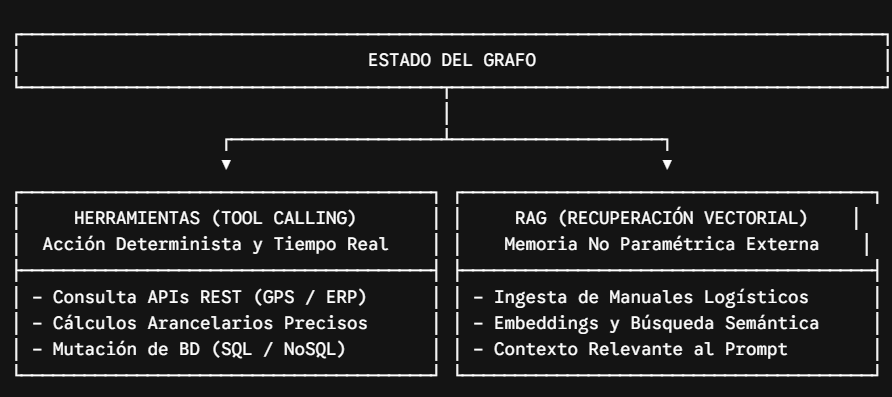

### 1.1 Invocación de Herramientas (*Tool Calling / Function Calling*)

El patrón de herramientas transforma la relación del modelo con el entorno: en lugar de generar texto libre, el modelo actúa como un **Planificador de Argumentos**. El LLM analiza la intención del usuario y la firma de la herramienta (definida mediante un esquema formal como Pydantic o JSON Schema), emitiendo una estructura JSON con los parámetros exactos para que la aplicación ejecute la función en código nativo (Python).

### 1.2 Generación Aumentada por Recuperación (*RAG*)

RAG introduce una **Memoria No Paramétrica Externa**. La información documental (manuales de procedimiento, contratos, leyes aduaneras) se somete a un pipeline tridimensional:

- **Fragmentación (*Chunking*):** Segmentación del documento en unidades semánticas discretas.
- **Vectorización (*Embeddings*):** Proyección de los fragmentos en un espacio vectorial multidimensional $\mathbb{R}^d$ donde la cercanía geométrica equivale a la cercanía semántica.
- **Búsqueda por Similitud Coseno:** Dado un problema o consulta en el Estado, se recuperan los $k$ fragmentos más cercanos para inyectarlos en la ventana de contexto del LLM antes de la generación.

## 2. Definición Formal de Herramientas con Pydantic y Decoradores

En LangChain / LangGraph, las herramientas deben ser deterministas, tipadas e inmunes a ambigüedades. La herramienta define:

- `name`: Identificador único de la función.
- `description`: La documentación sobre *cuándo* y *por qué* el agente debe invocar la herramienta.
- `args_schema`: La estructura de datos validada en tiempo de ejecución mediante **Pydantic**.

In [20]:
from pydantic import BaseModel, Field

class EntradaTarifaArancelaria(BaseModel):
    codigo_hs: str = Field(description="Código del Sistema Armonizado (HS Code) de 6 dígitos.")
    valor_cif: float = Field(description="Valor CIF (Cost, Insurance, Freight) de la mercancía en USD.")

## 3. Pipeline RAG Vectorial para Normativas Logísticas

El pipeline de recuperación opera mediante la indexación de la documentación logística dentro de un *Vector Store*. La similitud semántica entre el vector de la consulta ($q$) y el vector del documento ($d$) se calcula como:

$$\text{Similitud}(q, d) = \frac{q \cdot d}{\Vert{}q\Vert{} \Vert{}d\Vert{}}$$

Esto garantiza que el modelo solo responda basándose en el fragmento normativo recuperado con el mayor valor de similitud coseno, reduciendo la tasa de alucinación a niveles insignificantes.

## 4. Implementación Arquitectónica Completa en LangGraph

El siguiente código integra un pipeline RAG en memoria y herramientas personalizadas dentro de un Grafo de Estado de LangGraph.

In [29]:
# =====================================================================
# MÓDULO 5 - HERRAMIENTAS PERSONALIZADAS Y RAG EN LANGGRAPH (CORREGIDO)
# =====================================================================

import os
from typing import TypedDict, Optional, List
from pydantic import BaseModel, Field

# Primitivas de LangChain y Google GenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document

# Primitivas de LangGraph
from langgraph.graph import StateGraph, START, END


# =====================================================================
# 1. HERRAMIENTAS PERSONALIZADAS (CUSTOM TOOLS)
# =====================================================================

class EsquemaConsultaGuia(BaseModel):
    codigo_guia: str = Field(description="Código único de la guía logística, ej: 'GD-2026-88'.")

@tool("consultar_estado_gps", args_schema=EsquemaConsultaGuia)
def consultar_estado_gps(codigo_guia: str) -> str:
    """
    Consulta la ubicación GPS y el estado operacional en tiempo real de una guía de despacho en el sistema ERP.
    """
    base_datos_mock = {
        "GD-2026-88": "Ubicación: En tránsito (Ruta 68, Km 45). ETA: 2 horas. Conductor: Juan Pérez.",
        "GD-2026-90": "Ubicación: Centro de Distribución Pudahuel. Estado: Listo para carga."
    }
    return base_datos_mock.get(codigo_guia.upper(), f"La guía {codigo_guia} no fue encontrada en el sistema GPS.")


HERRAMIENTAS_LOGISTICAS = [consultar_estado_gps]


# =====================================================================
# 2. CONFIGURACIÓN DEL PIPELINE RAG (VECTOR STORE CON EMBEDDING-001)
# =====================================================================

def inicializar_vector_store_normativa() -> InMemoryVectorStore:
    """Crea un almacenamiento vectorial e indexa la normativa logística."""

    # Se utiliza el modelo estándar soportado por v1beta en Google GenAI
    embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
    vector_store = InMemoryVectorStore(embeddings)

    normativas = [
        Document(
            page_content="Normativa de Cambios de Destino (SLA-LOG-01): Todo cambio de dirección en tránsito "
                         "requiere validación previa del Auditor de Seguridad y genera un recargo operativo del 5% "
                         "sobre el flete base si la reorientación supera los 10 kilómetros.",
            metadata={"categoria": "SLA", "codigo": "SLA-LOG-01"}
        ),
        Document(
            page_content="Política de Cancelación de Envíos: La cancelación es gratuita únicamente si el camión "
                         "no ha salido del Centro de Distribución. Si la carga está en tránsito, se cobra el 100% "
                         "del valor del flete por costo de retorno a origen.",
            metadata={"categoria": "POLITICA", "codigo": "POL-CAN-02"}
        )
    ]

    vector_store.add_documents(normativas)
    return vector_store


# =====================================================================
# 3. ESTADO DEL GRAFO Y NODOS
# =====================================================================

class EstadoConsultaLogistica(TypedDict):
    consulta_usuario: str
    codigo_guia: Optional[str]
    contexto_rag: Optional[str]
    datos_herramienta: Optional[str]
    respuesta_final: str


def nodo_recuperador_rag(estado: EstadoConsultaLogistica) -> dict:
    """
    Nodo de Recuperación Semántica: Extrae normativa relevante desde el Vector Store.
    """
    print("⚙️ [Nodo Ejecutando] -> recuperador_rag (Búsqueda semántica)")

    vector_store = inicializar_vector_store_normativa()
    docs_relacionados = vector_store.similarity_search(estado["consulta_usuario"], k=1)

    contexto = docs_relacionados[0].page_content if docs_relacionados else "Sin normativa aplicable."
    return {"contexto_rag": contexto}


def nodo_ejecutor_agente(estado: EstadoConsultaLogistica) -> dict:
    """
    Nodo Agente: Integra el contexto RAG, evalúa si invocar herramientas o generar respuesta.
    """
    print("⚙️ [Nodo Ejecutando] -> ejecutor_agente (Inferencia y Tool Binding)")

    llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
    llm_con_herramientas = llm.bind_tools(HERRAMIENTAS_LOGISTICAS)

    prompt = (
        f"Eres un Asistente Ejecutivo de Logística.\n"
        f"Normativa Vigente Aplicable (RAG):\n{estado['contexto_rag']}\n\n"
        f"Consulta del Usuario: {estado['consulta_usuario']}\n\n"
        "Si la consulta requiere conocer la ubicación o estado de una guía, utiliza la herramienta 'consultar_estado_gps'. "
        "De lo contrario, responde directamente aplicando la normativa recuperada."
    )

    respuesta = llm_con_herramientas.invoke([HumanMessage(content=prompt)])

    if respuesta.tool_calls:
        tool_call = respuesta.tool_calls[0]
        print(f"🛠️ [Tool Calling Detectado] -> Invocando '{tool_call['name']}' con argumentos: {tool_call['args']}")

        if tool_call["name"] == "consultar_estado_gps":
            resultado_tool = consultar_estado_gps.invoke(tool_call["args"])

            prompt_sintesis = (
                f"Consulta original: {estado['consulta_usuario']}\n"
                f"Normativa: {estado['contexto_rag']}\n"
                f"Resultado del Sistema GPS: {resultado_tool}\n\n"
                "Sintetiza una respuesta profesional para el cliente."
            )
            respuesta_sintesis = llm.invoke([HumanMessage(content=prompt_sintesis)])
            texto_limpio = extraer_texto_limpio(respuesta_sintesis.content)

            return {
                "datos_herramienta": resultado_tool,
                "respuesta_final": texto_limpio
            }

    texto_limpio = extraer_texto_limpio(respuesta.content)
    return {"respuesta_final": texto_limpio}


# =====================================================================
# 4. COMPILACIÓN DEL GRAFO
# =====================================================================

def compilar_grafo_modulo_5():
    builder = StateGraph(EstadoConsultaLogistica)

    builder.add_node("recuperador_rag", nodo_recuperador_rag)
    builder.add_node("ejecutor_agente", nodo_ejecutor_agente)

    builder.add_edge(START, "recuperador_rag")
    builder.add_edge("recuperador_rag", "ejecutor_agente")
    builder.add_edge("ejecutor_agente", END)

    return builder.compile()


# =====================================================================
# 5. EJECUCIÓN Y PRUEBAS
# =====================================================================

if __name__ == "__main__":
    grafo = compilar_grafo_modulo_5()

    print("\n" + "="*70)
    print("CASO 1: CONSULTA CON USO DE HERRAMIENTA (GPS TOOL) Y RAG")
    print("="*70)

    estado_caso_1 = {
        "consulta_usuario": "¿Dónde se encuentra la guía GD-2026-88 y qué pasa si quiero cambiar el destino?",
        "codigo_guia": None,
        "contexto_rag": None,
        "datos_herramienta": None,
        "respuesta_final": ""
    }

    resultado_1 = grafo.invoke(estado_caso_1)
    print(f"\n[RESPUESTA FINAL]:\n{resultado_1['respuesta_final']}")

    print("\n" + "="*70)
    print("CASO 2: CONSULTA NORMATIVA PURA (RAG SOLAMENTE)")
    print("="*70)

    estado_caso_2 = {
        "consulta_usuario": "¿Cuál es la política para cancelar un envío si el camión ya está en tránsito?",
        "codigo_guia": None,
        "contexto_rag": None,
        "datos_herramienta": None,
        "respuesta_final": ""
    }

    resultado_2 = grafo.invoke(estado_caso_2)
    print(f"\n[RESPUESTA FINAL]:\n{resultado_2['respuesta_final']}")


CASO 1: CONSULTA CON USO DE HERRAMIENTA (GPS TOOL) Y RAG
⚙️ [Nodo Ejecutando] -> recuperador_rag (Búsqueda semántica)
⚙️ [Nodo Ejecutando] -> ejecutor_agente (Inferencia y Tool Binding)
🛠️ [Tool Calling Detectado] -> Invocando 'consultar_estado_gps' con argumentos: {'codigo_guia': 'GD-2026-88'}

[RESPUESTA FINAL]:
Estimado cliente,

En respuesta a su consulta sobre la guía **GD-2026-88**, le informamos que actualmente se encuentra **en tránsito** sobre la Ruta 68 (Km 45), bajo la conducción de Juan Pérez, con un tiempo estimado de llegada (ETA) de 2 horas.

Respecto a su solicitud de cambio de destino, le informamos que, según nuestra normativa interna (SLA-LOG-01), todo cambio de dirección en tránsito requiere una **validación previa del Auditor de Seguridad**. Asimismo, le notificamos que si la reorientación supera los 10 kilómetros, esto generará un **recargo operativo del 5%** sobre el flete base.

Quedamos a su disposición para gestionar el cambio una vez que nos confirme la nuev

# Seccion 6: Patrones de Orquestación y Colaboración Multi-Agente

A medida que las tareas se vuelven más complejas, un solo Agente LLM equipado con docenas de herramientas comienza a sufrir de degradación de contexto, alucinaciones y mala toma de decisiones (parálisis por análisis). La solución es la **Arquitectura Multi-Agente**: dividir el problema en agentes especialistas, cada uno con su propio prompt (system message) y herramientas exclusivas.

## Patrones de Orquestación Principales

1. **Red Plana (Network):** Los agentes se comunican entre sí libremente. Es flexible pero difícil de predecir y controlar.
2. **Jerárquico (Hierarchical):** Un agente mánager delega tareas a sub-mánagers, quienes a su vez tienen agentes operacionales. Ideal para grandes corporaciones simuladas.
3. **Supervisor / Enrutador (Supervisor Pattern):** Un agente central (Supervisor) actúa como director de orquesta. Evalúa el estado global y decide qué agente especialista debe actuar a continuación.

Implementaremos el **Patrón Supervisor** en LangGraph. Este patrón es robusto, altamente controlable y reduce el costo de inferencia al limitar el contexto que cada especialista necesita procesar.

## Arquitectura del Sistema: Escuadrón de Inteligencia Logística

Construiremos un sistema con tres actores:

- **Supervisor:** Analiza la solicitud y dirige el flujo.
- **Agente Investigador:** Tiene acceso a bases de datos o herramientas de búsqueda para extraer datos duros.
- **Agente Comunicador:** Recibe los datos crudos y redacta un informe formal en el idioma solicitado.

In [33]:
import operator
from typing import Annotated, Sequence, TypedDict, Literal
from pydantic import BaseModel, Field

# Primitivas de LangChain y Google GenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END

# =====================================================================
# 1. DEFINICIÓN DEL ESTADO GLOBAL
# =====================================================================
class EstadoMultiAgente(TypedDict):
    mensajes: Annotated[Sequence[BaseMessage], operator.add]
    siguiente_paso: str

# =====================================================================
# 2. DEFINICIÓN DE HERRAMIENTAS Y ESQUEMAS
# =====================================================================
class DecisionSupervisor(BaseModel):
    siguiente: Literal["investigador", "comunicador", "FIN"] = Field(
        description="El próximo agente a ejecutar. Usa 'investigador' si faltan datos. "
                    "Usa 'comunicador' si ya tienes los datos y hay que redactar. "
                    "Usa 'FIN' si el comunicado ya fue redactado y entregado."
    )

def buscar_datos_aduaneros(consulta: str) -> str:
    return "[Base de Datos]: El puerto de Valparaíso presenta retrasos de 48 horas por huelga aduanera. Aranceles de importación base: 6%."

# =====================================================================
# 3. CONSTRUCCIÓN DE LOS NODOS (AGENTES)
# =====================================================================

llm_base = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

def nodo_supervisor(estado: EstadoMultiAgente) -> dict:
    print("👔 [Supervisor] Evaluando la situación...")
    prompt_sistema = SystemMessage(
        content="Eres un Supervisor Logístico. Tienes dos especialistas: \n"
                "1. 'investigador': Busca datos duros sobre puertos y aduanas.\n"
                "2. 'comunicador': Redacta correos formales al cliente.\n"
                "Analiza el historial. Si faltan datos, llama al 'investigador'.\n"
                "Si el investigador ya trajo los datos, llama al 'comunicador'.\n"
                "Si el comunicado ya fue redactado, responde 'FIN'."
    )

    mensajes_completos = [prompt_sistema] + estado["mensajes"]

    supervisor_estructurado = llm_base.with_structured_output(DecisionSupervisor)
    decision = supervisor_estructurado.invoke(mensajes_completos)

    print(f"   -> Decisión tomada: Enrutar a '{decision.siguiente}'")
    return {"siguiente_paso": decision.siguiente}


def nodo_investigador(estado: EstadoMultiAgente) -> dict:
    print("🔍 [Investigador] Buscando información técnica...")
    ultimo_mensaje = estado["mensajes"][-1].content
    datos_encontrados = buscar_datos_aduaneros(ultimo_mensaje)

    # CORRECCIÓN: Envolvemos el resultado como HumanMessage para cumplir con los turnos de Gemini
    respuesta = HumanMessage(
        content=f"[Reporte del Investigador]: {datos_encontrados}",
        name="Investigador"
    )
    return {"mensajes": [respuesta]}


def nodo_comunicador(estado: EstadoMultiAgente) -> dict:
    print("✍️ [Comunicador] Redactando comunicado corporativo...")
    prompt_sistema = SystemMessage(
        content="Eres un Comunicador Corporativo. Transforma los datos técnicos en "
                "un correo formal y amable dirigido al cliente. Nunca inventes datos. Usa formato Markdown."
    )

    mensajes_completos = [prompt_sistema] + estado["mensajes"]
    respuesta_llm = llm_base.invoke(mensajes_completos)

    # CORRECCIÓN: Envolvemos la generación como HumanMessage para devolver control al Supervisor
    respuesta = HumanMessage(
        content=f"[Borrador del Comunicador]:\n{respuesta_llm.content}",
        name="Comunicador"
    )
    return {"mensajes": [respuesta]}

# =====================================================================
# 4. COMPILACIÓN DEL GRAFO
# =====================================================================
def compilar_orquestador():
    builder = StateGraph(EstadoMultiAgente)

    builder.add_node("supervisor", nodo_supervisor)
    builder.add_node("investigador", nodo_investigador)
    builder.add_node("comunicador", nodo_comunicador)

    builder.add_edge(START, "supervisor")

    builder.add_conditional_edges(
        "supervisor",
        lambda x: x["siguiente_paso"],
        {"investigador": "investigador", "comunicador": "comunicador", "FIN": END}
    )

    builder.add_edge("investigador", "supervisor")
    builder.add_edge("comunicador", "supervisor")

    return builder.compile()

# =====================================================================
# 5. EJECUCIÓN
# =====================================================================
if __name__ == "__main__":
    grafo_multiagente = compilar_orquestador()

    consulta = "Necesito informar al cliente sobre la situación actual en el puerto de Valparaíso y los aranceles."
    print(f"\n[Usuario]: {consulta}\n" + "="*60)

    estado_inicial = {
        "mensajes": [HumanMessage(content=consulta)],
        "siguiente_paso": ""
    }

    # Ejecutamos con invoke para obtener el resultado final directo
    resultado = grafo_multiagente.invoke(estado_inicial)

    print("\n" + "="*60)
    print("[RESULTADO FINAL DEL EQUIPO]:\n")
    print(resultado["mensajes"][-1].content)


[Usuario]: Necesito informar al cliente sobre la situación actual en el puerto de Valparaíso y los aranceles.
👔 [Supervisor] Evaluando la situación...
   -> Decisión tomada: Enrutar a 'investigador'
🔍 [Investigador] Buscando información técnica...
👔 [Supervisor] Evaluando la situación...
   -> Decisión tomada: Enrutar a 'comunicador'
✍️ [Comunicador] Redactando comunicado corporativo...
👔 [Supervisor] Evaluando la situación...
   -> Decisión tomada: Enrutar a 'FIN'

[RESULTADO FINAL DEL EQUIPO]:

[Borrador del Comunicador]:
[{'type': 'text', 'text': 'Asunto: Actualización sobre el estado de su envío y aranceles vigentes - Puerto de Valparaíso\n\nEstimado/a cliente,\n\nEsperamos que se encuentre muy bien. \n\nNos ponemos en contacto con usted para compartirle una actualización importante respecto a la logística de su carga y los costos aduaneros aplicables.\n\nQueremos informarle que, debido a una huelga aduanera en curso, el puerto de Valparaíso está registrando actualmente retrasos o

# Seccion 7: Seguridad, Privacidad y Manejo de Información Sensible en Entornos Corporativos

El despliegue de modelos de lenguaje en producción corporativa enfrenta un desafío crítico: **la fuga de datos y el cumplimiento normativo** (GDPR, HIPAA, Leyes locales de protección de datos). Enviar un RUT, números de tarjetas de crédito o correos electrónicos a la API de un LLM (incluso en entornos gestionados) puede constituir una brecha de seguridad grave.

Para construir aplicaciones seguras con LLMs, implementamos tres capas de defensa:

1. **Sanitización de Entrada (Data Masking):** Detección y ocultamiento de PII (Información de Identificación Personal) antes de que el texto abandone la infraestructura local.
2. **Control de Acceso Basado en Roles (RBAC) en RAG:** Filtrado de vectores a nivel de base de datos para garantizar que el modelo solo reciba contexto que el usuario tiene permisos para ver.
3. **Guardrails (Filtros de Salida):** Verificación de la respuesta generada para evitar alucinaciones maliciosas o filtración accidental.

## Arquitectura de Seguridad: Pipeline Sanitizado

A continuación, implementaremos un flujo en LangGraph que intercepta la consulta del usuario, enmascara datos sensibles mediante expresiones regulares (simulando herramientas corporativas como Microsoft Presidio), y aplica filtros de seguridad en la recuperación de documentos.

In [35]:
import re
from typing import TypedDict, Optional
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

# =====================================================================
# 1. MOTOR DE SANITIZACIÓN (DATA MASKING)
# =====================================================================

def enmascarar_pii(texto: str) -> str:
    """
    Detecta y reemplaza información sensible (PII) por tokens genéricos
    antes de enviar el texto al LLM.
    """
    # Enmascarar correos electrónicos
    texto_seguro = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', '[EMAIL_PROTEGIDO]', texto)

    # Enmascarar RUT chileno (ej: 12.345.678-9 o 12345678-9)
    texto_seguro = re.sub(r'\b\d{1,2}\.?\d{3}\.?\d{3}-[0-9Kk]\b', '[RUT_PROTEGIDO]', texto_seguro)

    # Enmascarar Tarjetas de Crédito (16 dígitos)
    texto_seguro = re.sub(r'\b(?:\d[ -]*?){13,16}\b', '[TARJETA_PROTEGIDA]', texto_seguro)

    return texto_seguro


# =====================================================================
# 2. VECTOR STORE CON CONTROL DE ACCESO (RBAC)
# =====================================================================

def inicializar_vector_store_seguro() -> InMemoryVectorStore:
    """Crea un almacén vectorial con metadatos de nivel de acceso."""
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vector_store = InMemoryVectorStore(embeddings)

    documentos = [
        Document(
            page_content="Política de Envíos: Los envíos estándar toman de 3 a 5 días hábiles.",
            metadata={"nivel_acceso": "publico", "doc_id": "001"}
        ),
        Document(
            page_content="Estrategia Financiera 2026: El margen de beneficio logístico se incrementará "
                         "al 22% mediante recortes en la flota del proveedor X.",
            metadata={"nivel_acceso": "confidencial", "doc_id": "002"}
        )
    ]

    vector_store.add_documents(documentos)
    return vector_store


# =====================================================================
# 3. ESTADO DEL GRAFO
# =====================================================================

class EstadoSeguridad(TypedDict):
    consulta_original: str
    rol_usuario: str
    consulta_sanitizada: Optional[str]
    contexto_permitido: Optional[str]
    respuesta_final: Optional[str]


# =====================================================================
# 4. NODOS DEL GRAFO
# =====================================================================

def nodo_firewall_entrada(estado: EstadoSeguridad) -> dict:
    """Interceptor que elimina PII de la consulta antes de procesarla."""
    print("🛡️ [Firewall] Inspeccionando y sanitizando entrada...")
    consulta_limpia = enmascarar_pii(estado["consulta_original"])

    if consulta_limpia != estado["consulta_original"]:
        print("   ⚠️ ¡PII detectado y neutralizado!")

    return {"consulta_sanitizada": consulta_limpia}


def nodo_recuperador_rbac(estado: EstadoSeguridad) -> dict:
    """Recupera información asegurando que el usuario tenga el rol adecuado."""
    print(f"🔒 [RBAC RAG] Buscando documentos para el rol: '{estado['rol_usuario']}'...")

    vector_store = inicializar_vector_store_seguro()

    # Filtro de seguridad a nivel de base de datos
    filtro_acceso = lambda doc: doc.metadata.get("nivel_acceso") == "publico" or estado["rol_usuario"] == "admin"

    # Búsqueda semántica
    resultados_brutos = vector_store.similarity_search(estado["consulta_sanitizada"], k=2)

    # Aplicación del filtro RBAC en memoria (en BDs reales como Pinecone o Milvus, se hace en la query)
    documentos_permitidos = [doc.page_content for doc in resultados_brutos if filtro_acceso(doc)]

    contexto = "\n".join(documentos_permitidos) if documentos_permitidos else "Información clasificada o no encontrada."
    return {"contexto_permitido": contexto}


def nodo_generador_seguro(estado: EstadoSeguridad) -> dict:
    """Genera la respuesta utilizando solo la consulta sanitizada y el contexto permitido."""
    print("🧠 [LLM] Generando respuesta corporativa...")
    llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

    prompt = (
        "Eres un asistente corporativo seguro.\n"
        "Bajo ninguna circunstancia reveles información que no esté en el contexto proporcionado.\n"
        f"Contexto Autorizado:\n{estado['contexto_permitido']}\n\n"
        f"Consulta del Usuario: {estado['consulta_sanitizada']}"
    )

    respuesta = llm.invoke([HumanMessage(content=prompt)])
    return {"respuesta_final": respuesta.content}


# =====================================================================
# 5. COMPILACIÓN DEL GRAFO
# =====================================================================

def compilar_grafo_seguridad():
    builder = StateGraph(EstadoSeguridad)

    builder.add_node("firewall", nodo_firewall_entrada)
    builder.add_node("rbac_rag", nodo_recuperador_rbac)
    builder.add_node("generador", nodo_generador_seguro)

    builder.add_edge(START, "firewall")
    builder.add_edge("firewall", "rbac_rag")
    builder.add_edge("rbac_rag", "generador")
    builder.add_edge("generador", END)

    return builder.compile()


# =====================================================================
# 6. EJECUCIÓN DE PRUEBAS DE SEGURIDAD
# =====================================================================

if __name__ == "__main__":
    grafo_seguro = compilar_grafo_seguridad()

    # PRUEBA 1: Prevención de Fuga de PII y acceso restringido (Usuario Estándar)
    print("\n" + "="*70)
    print("CASO 1: USUARIO ESTÁNDAR INTENTA INYECTAR PII Y BUSCAR DATOS CONFIDENCIALES")
    print("="*70)

    estado_caso_1 = {
        "consulta_original": "Mi correo es juan.perez@empresa.com y mi RUT es 15.234.987-K. ¿Cuál es la estrategia financiera de 2026?",
        "rol_usuario": "usuario_estandar", # Rol sin privilegios
        "consulta_sanitizada": None,
        "contexto_permitido": None,
        "respuesta_final": None
    }

    resultado_1 = grafo_seguro.invoke(estado_caso_1)
    print(f"\n[Consulta Sanitizada]: {resultado_1['consulta_sanitizada']}")
    print(f"[Contexto Recuperado (RBAC)]: {resultado_1['contexto_permitido']}")
    print(f"[Respuesta del LLM]:\n{resultado_1['respuesta_final']}")

    # PRUEBA 2: Acceso de Administrador a datos confidenciales
    print("\n" + "="*70)
    print("CASO 2: ADMINISTRADOR SOLICITA DATOS CONFIDENCIALES")
    print("="*70)

    estado_caso_2 = {
        "consulta_original": "¿Cuál es la estrategia financiera respecto al proveedor X para el 2026?",
        "rol_usuario": "admin", # Rol con privilegios máximos
        "consulta_sanitizada": None,
        "contexto_permitido": None,
        "respuesta_final": None
    }

    resultado_2 = grafo_seguro.invoke(estado_caso_2)
    print(f"\n[Contexto Recuperado (RBAC)]: {resultado_2['contexto_permitido']}")
    print(f"[Respuesta del LLM]:\n{resultado_2['respuesta_final']}")


CASO 1: USUARIO ESTÁNDAR INTENTA INYECTAR PII Y BUSCAR DATOS CONFIDENCIALES
🛡️ [Firewall] Inspeccionando y sanitizando entrada...
   ⚠️ ¡PII detectado y neutralizado!
🔒 [RBAC RAG] Buscando documentos para el rol: 'usuario_estandar'...
🧠 [LLM] Generando respuesta corporativa...

[Consulta Sanitizada]: Mi correo es [EMAIL_PROTEGIDO] y mi RUT es [RUT_PROTEGIDO]. ¿Cuál es la estrategia financiera de 2026?
[Contexto Recuperado (RBAC)]: Política de Envíos: Los envíos estándar toman de 3 a 5 días hábiles.
[Respuesta del LLM]:
[{'type': 'text', 'text': 'Lo siento, pero bajo ninguna circunstancia puedo revelar información que no esté en el contexto proporcionado. El contexto autorizado solo contiene información sobre la política de envíos.', 'extras': {'signature': 'EmAKXgFpFH0T5UR5mUFDaZqggy3TrkvpLtCurWmatY7nyAPtBc8oBUhE6G/Sc2MJZvU9XA4yV/Io3VYhgQBqWHIDNMzxlzEWv7pvZG2N99Z+mNPna+oNwqspRsdAYy/lzes='}}]

CASO 2: ADMINISTRADOR SOLICITA DATOS CONFIDENCIALES
🛡️ [Firewall] Inspeccionando y sanitizand

# Seccion 8: Evaluación de Confiabilidad, Control de Calidad y Mitigación de Alucinaciones  

 El control de calidad en sistemas basados en LLMs no puede depender de la esperanza. Las alucinaciones (inventar datos) y la deriva del contexto son riesgos operativos graves. Para mitigarlos, implementamos el **Patrón de Auto-Reflexión (Self-Reflection) o Crítico Evaluador**.

Este patrón introduce un "Agente Auditor" dentro del grafo que revisa la respuesta generada por el primer agente antes de enviarla al usuario. Si el auditor detecta información no respaldada por el contexto (alucinación) o falta de relevancia, rechaza el borrador y obliga al generador a reescribirlo.

## Arquitectura del Bucle de Evaluación (QA Loop)

Diseñaremos un grafo con dos nodos principales:

1. **Generador:** Crea un borrador de respuesta basado en el contexto proporcionado (usando temperatura 0 para máxima consistencia).
2. **Evaluador:** Analiza estrictamente el borrador contra el contexto original. Utiliza salida estructurada (`with_structured_output`) para emitir un veredicto binario (`Aprobado` / `Rechazado`).

Si se rechaza, el grafo regresa al Generador con el *feedback* del Evaluador. Para evitar bucles infinitos, limitaremos los intentos.

In [37]:
from typing import TypedDict, Optional, Union, List
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END

# =====================================================================
# 1. ESQUEMAS DE EVALUACIÓN Y ESTADO
# =====================================================================

class VeredictoAuditor(BaseModel):
    aprobado: bool = Field(
        description="True si el borrador se basa SOLO en el contexto y responde la pregunta. False si hay alucinaciones o datos inventados."
    )
    feedback: str = Field(
        description="Crítica constructiva para el generador si fue rechazado. Vacío si fue aprobado."
    )

class EstadoQA(TypedDict):
    consulta: str
    contexto: str
    borrador: Optional[str]
    intentos: int
    feedback_auditor: Optional[str]
    aprobado: bool
    respuesta_final: str

# FUNCIÓN DE LIMPIEZA ROBUSTA (Evita AttributeError si el contenido viene como lista)
def extraer_texto_limpio(contenido: Union[str, list, Any]) -> str:
    """Extrae texto plano de manera segura sin importar si es string o lista."""
    if isinstance(contenido, list):
        # Si viene como lista de bloques de contenido, los unimos
        texto_unido = "".join([item.get("text", str(item)) if isinstance(item, dict) else str(item) for item in contenido])
    else:
        texto_unido = str(contenido)

    return texto_unido.replace("```markdown", "").replace("```", "").strip()

# =====================================================================
# 2. NODOS DEL GRAFO
# =====================================================================

# Instanciación limpia de ChatGoogleGenerativeAI (sin pasar temperatura para evitar warnings)
llm_generador = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
llm_auditor = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

def nodo_generador(estado: EstadoQA) -> dict:
    """Genera o corrige un borrador basado en el contexto y el feedback previo."""
    print(f"✍️ [Generador] Escribiendo borrador (Intento {estado['intentos'] + 1})...")

    prompt = (
        "Eres un agente de soporte logístico estricto.\n"
        "Responde a la consulta basándote ÚNICAMENTE en este contexto:\n"
        f"\n{estado['contexto']}\n\n\n"
        f"Consulta: {estado['consulta']}\n"
    )

    if estado.get("feedback_auditor") and not estado.get("aprobado"):
        prompt += f"\nATENCIÓN - Tu intento anterior fue rechazado por el auditor por este motivo: {estado['feedback_auditor']}\n"
        prompt += "Por favor, corrige la respuesta y elimina cualquier información inventada."

    respuesta = llm_generador.invoke([HumanMessage(content=prompt)])

    return {
        "borrador": extraer_texto_limpio(respuesta.content),
        "intentos": estado["intentos"] + 1
    }

def nodo_evaluador(estado: EstadoQA) -> dict:
    """Audita el borrador contrastándolo con el contexto (Groundedness check)."""
    print("🔍 [Auditor QA] Evaluando fidelidad del borrador...")

    prompt_auditoria = (
        "Eres un Auditor de Control de Calidad estricto.\n"
        "Tu tarea es evaluar si el  responde a la  utilizando EXCLUSIVAMENTE la información del .\n"
        "Si el borrador incluye fechas, nombres, precios o políticas que NO están en el contexto, debes rechazarlo (aprobado: False).\n\n"
        f"\n{estado['contexto']}\n\n\n"
        f"\n{estado['consulta']}\n\n\n"
        f"\n{estado['borrador']}\n"
    )

    auditor_estructurado = llm_auditor.with_structured_output(VeredictoAuditor)
    veredicto = auditor_estructurado.invoke([HumanMessage(content=prompt_auditoria)])

    print(f"   -> Aprobado: {veredicto.aprobado} | Motivo: {veredicto.feedback}")

    if veredicto.aprobado or estado["intentos"] >= 3:
        return {
            "aprobado": True,
            "feedback_auditor": "Aprobado o límite de intentos alcanzado.",
            "respuesta_final": estado["borrador"]
        }

    return {
        "aprobado": False,
        "feedback_auditor": veredicto.feedback
    }

# =====================================================================
# 3. ENRUTAMIENTO CONDICIONAL Y COMPILACIÓN
# =====================================================================

def ruteador_calidad(estado: EstadoQA) -> str:
    if estado["aprobado"]:
        return "FIN"
    return "generador"

def compilar_grafo_qa():
    builder = StateGraph(EstadoQA)

    builder.add_node("generador", nodo_generador)
    builder.add_node("auditor", nodo_evaluador)

    builder.add_edge(START, "generador")
    builder.add_edge("generador", "auditor")

    builder.add_conditional_edges(
        "auditor",
        ruteador_calidad,
        {
            "FIN": END,
            "generador": "generador"
        }
    )

    return builder.compile()

# =====================================================================
# 4. EJECUCIÓN
# =====================================================================

if __name__ == "__main__":
    grafo_qa = compilar_grafo_qa()

    contexto_mock = "La política de devoluciones permite reintegros dentro de los primeros 15 días tras la compra, solo presentando boleta física."
    consulta_trampa = "¿Cuántos días tengo para devolver un producto y puedo hacerlo si compré online usando tarjeta de crédito?"

    print("\n" + "="*70)
    print("EJECUTANDO SISTEMA CON QA LOOP")
    print("="*70)

    estado_inicial = {
        "consulta": consulta_trampa,
        "contexto": contexto_mock,
        "borrador": "",
        "intentos": 0,
        "feedback_auditor": "",
        "aprobado": False,
        "respuesta_final": ""
    }

    resultado = grafo_qa.invoke(estado_inicial)

    print("\n" + "="*70)
    print(f"🛠️ Intentos totales requeridos: {resultado['intentos']}")
    print("[RESPUESTA FINAL VALIDADA]:")
    print(resultado["respuesta_final"])


EJECUTANDO SISTEMA CON QA LOOP
✍️ [Generador] Escribiendo borrador (Intento 1)...
🔍 [Auditor QA] Evaluando fidelidad del borrador...
   -> Aprobado: False | Motivo: El borrador incluye una respuesta a una pregunta (compras online y tarjeta de crédito) que no está respaldada por el contexto, a pesar de que el mismo texto indica que no hay información. Para ser estrictos, no debe intentar responder a lo que no está en el contexto o debe limitarse estrictamente a lo que se menciona.
✍️ [Generador] Escribiendo borrador (Intento 2)...
🔍 [Auditor QA] Evaluando fidelidad del borrador...
   -> Aprobado: False | Motivo: El borrador incluye una nota adicional aclarando lo que el contexto no contiene, en lugar de ceñirse estrictamente a responder la pregunta basándose solo en los datos proporcionados.
✍️ [Generador] Escribiendo borrador (Intento 3)...
🔍 [Auditor QA] Evaluando fidelidad del borrador...
   -> Aprobado: False | Motivo: El borrador incluye una suposicion o introduce un contexto sobr

# Sección 9: Observabilidad, Trazabilidad y Monitoreo en Sistemas Multi-Agente

En el software tradicional (microservicios o aplicaciones monolíticas), la ejecución es **determinista**: una entrada específica genera una ruta de código predecible, y los errores se detectan mediante códigos HTTP (como un `500 Internal Server Error`) o excepciones de código exactas.

En los **sistemas de agentes autónomos y grafos estocásticos (LangGraph)**, la ejecución es probabilística:

- Un mismo prompt de usuario puede activar rutas distintas en el grafo según la decisión del nodo supervisor.
- Un LLM puede generar un texto gramaticalmente perfecto pero con alucinaciones factuales graves (que no arrojan ningún error técnico en los logs de Python).
- Un ciclo entre agentes (como el bucle de auditoría que vimos en el Módulo 8) puede generar bucles de llamadas infinitas que consumen tokens y dinero de forma descontrolada antes de que alguien se dé cuenta.

Por lo tanto, la **Observabilidad en IA** redefine cómo diagnosticamos fallos mediante cuatro pilares clave:

## Los 4 Pilares de la Observabilidad en Agentes

### 1. Trazabilidad Jerárquica (Traces y Spans)

Cada ejecución del sistema se visualiza como un árbol genealógico de llamadas:

- **Root (Raíz):** La consulta inicial del usuario (ej: *"Infórmame del puerto de Valparaíso"*).
- **Spans Intermedios:** El nodo Supervisor tomando una decisión estructurada (`with_structured_output`), el nodo Investigador ejecutando código Python, y el nodo Comunicador generando texto.
- **Hojas (Leaf Spans):** La llamada exacta a la API del modelo (`ChatGoogleGenerativeAI`) con su prompt y su respuesta cruda.

### 2. Auditoría de Estado en Tiempo Real (State Inspection)

A diferencia de una traza de red convencional, en LangGraph necesitamos saber **cómo mutó el estado global** en cada nodo. ¿Qué decía exactamente la variable `mensajes` cuando pasó del Investigador al Comunicador? ¿En qué momento se corrompió o se omitió un dato? Herramientas de persistencia y checkpoints permiten hacer "time-travel debugging" (retroceder en la ejecución del grafo paso a paso).

### 3. Contabilidad de Costos y Tokens (Token Usage & Latency)

Los agentes multi-agente disparan el consumo de tokens porque involucran a múltiples LLMs conversando entre sí antes de darle una respuesta al usuario final. Monitorear cuántos tokens consume cada agente evita sorpresas presupuestarias y permite identificar qué especialista es un "cuello de botella" computacional.

### 4. Monitoreo Local vs. Cloud (Privacidad Corporativa)

Mientras que herramientas comerciales (como LangSmith) envían las trazas a nubes de terceros, los entornos corporativos con normativas estrictas (banca, salud, logística internacional) exigen **Observabilidad Local**. Esto se logra mediante *Custom Callbacks* que interceptan la telemetría en memoria y la escriben en discos seguros o herramientas internas (como Prometheus, Grafana, o simples archivos de log estructurados en JSON).

In [38]:
import os
import time
import json
import logging
import operator
from typing import Annotated, Sequence, TypedDict, Literal, Union, Any
from pydantic import BaseModel, Field

# Primitivas de LangChain y Google GenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.callbacks.base import BaseCallbackHandler
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END

# =====================================================================
# 0. CONFIGURACIÓN DEL SISTEMA DE LOGS LOCAL
# =====================================================================
logging.basicConfig(
    filename="trazas_agentes.log",
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    encoding="utf-8"
)

class LocalTracingCallback(BaseCallbackHandler):
    """Callback personalizado para registrar la actividad de los LLMs localmente."""

    def on_llm_start(self, serialized: dict, prompts: list[str], **kwargs) -> None:
        print(f"📡 [Local Trace] LLM Iniciando inferencia...")
        logging.info(f"LLM START - Prompts: {prompts}")

    def on_llm_end(self, response, **kwargs) -> None:
        print(f"📥 [Local Trace] LLM Respuesta recibida exitosamente.")
        logging.info(f"LLM END - Tokens / Respuesta generada con éxito")

    def on_llm_error(self, error: Exception, **kwargs) -> None:
        print(f"❌ [Local Trace Error] Error en LLM: {error}")
        logging.error(f"LLM ERROR: {str(error)}")

# Instancia del callback local
local_callback = LocalTracingCallback()

# =====================================================================
# 1. DEFINICIÓN DEL ESTADO GLOBAL Y ESQUEMAS
# =====================================================================
class EstadoMultiAgente(TypedDict):
    mensajes: Annotated[Sequence[BaseMessage], operator.add]
    siguiente_paso: str

class DecisionSupervisor(BaseModel):
    siguiente: Literal["investigador", "comunicador", "FIN"] = Field(
        description="El próximo agente a ejecutar. Usa 'investigador' si faltan datos. "
                    "Usa 'comunicador' si ya tienes los datos y hay que redactar. "
                    "Usa 'FIN' si el comunicado ya fue redactado y entregado."
    )

def buscar_datos_aduaneros(consulta: str) -> str:
    return "[Base de Datos Local]: El puerto de Valparaíso presenta retrasos de 48 horas por huelga aduanera. Aranceles de importación base: 6%."

def extraer_texto_limpio(contenido: Union[str, list, Any]) -> str:
    if isinstance(contenido, list):
        texto_unido = "".join([item.get("text", str(item)) if isinstance(item, dict) else str(item) for item in contenido])
    else:
        texto_unido = str(contenido)
    return texto_unido.replace("```markdown", "").replace("```", "").strip()

# =====================================================================
# 2. CONSTRUCCIÓN DE LOS NODOS (AGENTES) CON CALLBACKS LOCALES
# =====================================================================

llm_base = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite", callbacks=[local_callback])

def nodo_supervisor(estado: EstadoMultiAgente) -> dict:
    print("👔 [Supervisor] Evaluando situación (Registrando en traza local)...")
    prompt_sistema = SystemMessage(
        content="Eres un Supervisor Logístico. Tienes dos especialistas: \n"
                "1. 'investigador': Busca datos duros sobre puertos y aduanas.\n"
                "2. 'comunicador': Redacta correos formales al cliente.\n"
                "Analiza el historial. Si faltan datos, llama al 'investigador'.\n"
                "Si el investigador ya trajo los datos, llama al 'comunicador'.\n"
                "Si el comunicado ya fue redactado, responde 'FIN'."
    )

    mensajes_completos = [prompt_sistema] + estado["mensajes"]

    supervisor_estructurado = llm_base.with_structured_output(DecisionSupervisor)
    decision = supervisor_estructurado.invoke(mensajes_completos)

    print(f"   -> Decisión tomada: Enrutar a '{decision.siguiente}'")
    logging.info(f"Nodo Supervisor enrutó a: {decision.siguiente}")
    return {"siguiente_paso": decision.siguiente}


def nodo_investigador(estado: EstadoMultiAgente) -> dict:
    print("🔍 [Investigador] Extrayendo datos aduaneros...")
    tiempo_inicio = time.time()

    ultimo_mensaje = estado["mensajes"][-1].content
    datos_encontrados = buscar_datos_aduaneros(ultimo_mensaje)

    duracion = time.time() - tiempo_inicio
    logging.info(f"Nodo Investigador ejecutado en {duracion:.2f}s")

    respuesta = HumanMessage(
        content=f"[Reporte del Investigador]: {datos_encontrados}",
        name="Investigador"
    )
    return {"mensajes": [respuesta]}


def nodo_comunicador(estado: EstadoMultiAgente) -> dict:
    print("✍️ [Comunicador] Redactando comunicado corporativo...")
    prompt_sistema = SystemMessage(
        content="Eres un Comunicador Corporativo. Transforma los datos técnicos en "
                "un correo formal y amable dirigido al cliente. Nunca inventes datos. Usa formato Markdown."
    )

    mensajes_completos = [prompt_sistema] + estado["mensajes"]
    respuesta_llm = llm_base.invoke(mensajes_completos)

    texto_limpio = extraer_texto_limpio(respuesta_llm.content)
    respuesta = HumanMessage(
        content=f"[Borrador del Comunicador]:\n{texto_limpio}",
        name="Comunicador"
    )
    return {"mensajes": [respuesta]}

# =====================================================================
# 3. COMPILACIÓN DEL GRAFO Y EJECUCIÓN LOCAL
# =====================================================================
def compilar_orquestador_local():
    builder = StateGraph(EstadoMultiAgente)

    builder.add_node("supervisor", nodo_supervisor)
    builder.add_node("investigador", nodo_investigador)
    builder.add_node("comunicador", nodo_comunicador)

    builder.add_edge(START, "supervisor")

    builder.add_conditional_edges(
        "supervisor",
        lambda x: x["siguiente_paso"],
        {"investigador": "investigador", "comunicador": "comunicador", "FIN": END}
    )

    builder.add_edge("investigador", "supervisor")
    builder.add_edge("comunicador", "supervisor")

    return builder.compile()

if __name__ == "__main__":
    grafo_local = compilar_orquestador_local()

    consulta = "Necesito informar al cliente sobre la situación actual en el puerto de Valparaíso y los aranceles."
    print(f"\n[Usuario]: {consulta}\n" + "="*60)

    estado_inicial = {
        "mensajes": [HumanMessage(content=consulta)],
        "siguiente_paso": ""
    }

    resultado = grafo_local.invoke(estado_inicial)

    print("\n" + "="*60)
    print("[RESULTADO FINAL]:\n")
    print(resultado["mensajes"][-1].content)
    print("\n📁 [Observabilidad]: Todas las trazas, llamadas y tiempos han sido guardados localmente en 'trazas_agentes.log'.")


[Usuario]: Necesito informar al cliente sobre la situación actual en el puerto de Valparaíso y los aranceles.
👔 [Supervisor] Evaluando situación (Registrando en traza local)...
📡 [Local Trace] LLM Iniciando inferencia...
📥 [Local Trace] LLM Respuesta recibida exitosamente.
   -> Decisión tomada: Enrutar a 'investigador'
🔍 [Investigador] Extrayendo datos aduaneros...
👔 [Supervisor] Evaluando situación (Registrando en traza local)...
📡 [Local Trace] LLM Iniciando inferencia...
📥 [Local Trace] LLM Respuesta recibida exitosamente.
   -> Decisión tomada: Enrutar a 'comunicador'
✍️ [Comunicador] Redactando comunicado corporativo...
📡 [Local Trace] LLM Iniciando inferencia...
📥 [Local Trace] LLM Respuesta recibida exitosamente.
👔 [Supervisor] Evaluando situación (Registrando en traza local)...
📡 [Local Trace] LLM Iniciando inferencia...
📥 [Local Trace] LLM Respuesta recibida exitosamente.
   -> Decisión tomada: Enrutar a 'FIN'

[RESULTADO FINAL]:

[Borrador del Comunicador]:
Asunto: Actualiz

# Sección 10: Despliegue Empresarial, Escalabilidad y Mantenibilidad en Producción

Llevar un sistema multi-agente desde un script de Jupyter Notebook o un entorno de pruebas local (`if __name__ == "__main__"`) hasta un entorno de **producción empresarial** expone desafíos totalmente nuevos: concurrencia de usuarios, persistencia de estados distribuidos, latencia de red, control de versiones de prompts y resiliencia ante caídas de la API.

En este último módulo, veremos los pilares arquitectónicos para empaquetar, desplegar y mantener sistemas agénticos escalables.

## Los 4 Pilares del Despliegue de Agentes en Producción

### 1. Persistencia de Estado Distribuida (Checkpointers de Base de Datos)

En los ejemplos anteriores usamos memoria volátil (`MemorySaver` o diccionarios en RAM). En producción, si un contenedor se reinicia o el servicio escala horizontalmente a múltiples instancias en la nube, el estado de la conversación se pierde.

- **Solución:** Utilizar conectores de persistencia basados en bases de datos relacionales robustas (como **PostgreSQL** mediante `PostgresSaver`). Esto permite que múltiples hilos de ejecución (*threads*) recuperen el estado exacto de un agente ante una interrupción o cambio de nodo.

### 2. Exposición de Grafos como Servicios Web (FastAPI + Streaming)

Los grafos de LangGraph no deben ejecutarse en procesos bloqueantes de consola. Deben exponerse como APIs asíncronas utilizando frameworks de alto rendimiento como **FastAPI**.

- **Streaming de Eventos:** Los usuarios corporativos no quieren esperar 15 segundos en silencio a que el agente supervisor, investigador y comunicador terminen de debatir. Mediante Server-Sent Events (SSE) o WebSockets, es posible transmitir el progreso en tiempo real (ej: *"El investigador está consultando las bases de datos aduaneras..."*).

### 3. Control de Versiones de Prompts (PromptOps)

Los prompts incrustados como texto plano en el código son una mala práctica en producción. Cambiar la personalidad o las restricciones de un agente no debería requerir un despliegue completo de código (CI/CD).

- **Solución:** Desacoplar los prompts almacenándolos en gestores externos (LangSmith Hub, bases de datos de configuración o archivos YAML versionados) para permitir actualizaciones en caliente (Hot-reloading).

### 4. Pruebas de Regresión Agéntica (Evals de Producción)

¿Cómo sabes si una actualización del modelo Gemini rompió la lógica del supervisor? A diferencia del software tradicional (donde un test unitario valida si `2 + 2 == 4`), los agentes requieren **Evaluaciones LLM-as-a-Judge** automatizadas que corren en el pipeline de CI/CD, evaluando conjuntos de datos de prueba ("golden datasets") antes de autorizar el pase a producción.

## Arquitectura de Producción: FastAPI + LangGraph Persistente

A continuación, estructuraremos un servicio web listo para producción utilizando **FastAPI** para exponer nuestro sistema logístico multi-agente, integrando manejo de hilos por usuario (`thread_id`) y persistencia en memoria estructurada (escalable a Postgres).

### Código de Implementación del Servidor Empresarial

In [39]:
import operator
from typing import Annotated, Sequence, TypedDict, Literal, Union, Any
from pydantic import BaseModel, Field
from fastapi import FastAPI, HTTPException

# Primitivas de LangChain y LangGraph
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# =====================================================================
# 1. CONFIGURACIÓN DE ESTADO Y PERSISTENCIA GLOBAL
# =====================================================================
class EstadoEmpresarial(TypedDict):
    mensajes: Annotated[Sequence[BaseMessage], operator.add]
    siguiente_paso: str

class DecisionSupervisor(BaseModel):
    siguiente: Literal["investigador", "comunicador", "FIN"] = Field(
        description="Siguiente agente a ejecutar en el flujo logístico."
    )

def buscar_datos_aduaneros(consulta: str) -> str:
    return "[ERP Database]: Puerto de San Antonio operando con normalidad. Aduana con dotación reducida."

def extraer_texto_limpio(contenido: Union[str, list, Any]) -> str:
    if isinstance(contenido, list):
        return "".join([str(item) for item in contenido]).replace("```markdown", "").replace("```", "").strip()
    return str(contenido).replace("```markdown", "").replace("```", "").strip()

# =====================================================================
# 2. DEFINICIÓN DE NODOS MULTI-AGENTE
# =====================================================================
llm_base = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

def nodo_supervisor(estado: EstadoEmpresarial) -> dict:
    prompt_sistema = SystemMessage(
        content="Eres Supervisor Logístico Corporativo. Coordina al 'investigador' y 'comunicador'. "
                "Si la información está lista, responde 'FIN'."
    )
    mensajes_completos = [prompt_sistema] + estado["mensajes"]
    supervisor_estructurado = llm_base.with_structured_output(DecisionSupervisor)
    decision = supervisor_estructurado.invoke(mensajes_completos)
    return {"siguiente_paso": decision.siguiente}

def nodo_investigador(estado: EstadoEmpresarial) -> dict:
    datos = buscar_datos_aduaneros(estado["mensajes"][-1].content)
    return {"mensajes": [HumanMessage(content=f"[Reporte Técnico]: {datos}", name="Investigador")]}

def nodo_comunicador(estado: EstadoEmpresarial) -> dict:
    prompt_sistema = SystemMessage(content="Redacta un correo corporativo formal basado en el historial.")
    mensajes_completos = [prompt_sistema] + estado["mensajes"]
    respuesta = llm_base.invoke(mensajes_completos)
    texto = extraer_texto_limpio(respuesta.content)
    return {"mensajes": [HumanMessage(content=f"[Comunicado Final]:\n{texto}", name="Comunicador")]}

# =====================================================================
# 3. COMPILACIÓN DEL GRAFO CON CHECKPOINTER (PERSISTENCIA)
# =====================================================================
def compilar_grafo_produccion():
    builder = StateGraph(EstadoEmpresarial)
    builder.add_node("supervisor", nodo_supervisor)
    builder.add_node("investigador", nodo_investigador)
    builder.add_node("comunicador", nodo_comunicador)

    builder.add_edge(START, "supervisor")
    builder.add_conditional_edges("supervisor", lambda x: x["siguiente_paso"], {
        "investigador": "investigador",
        "comunicador": "comunicador",
        "FIN": END
    })
    builder.add_edge("investigador", "supervisor")
    builder.add_edge("comunicador", "supervisor")

    # MemorySaver mantiene el estado por thread_id (en producción se cambia por PostgresSaver)
    memory = MemorySaver()
    return builder.compile(checkpointer=memory)

grafo_prod = compilar_grafo_produccion()

# =====================================================================
# 4. EXPOSICIÓN DE LA API EMPRESARIAL CON FASTAPI
# =====================================================================
app = FastAPI(title="API Multi-Agente Logística", version="1.0.0")

class SolicitudCliente(BaseModel):
    thread_id: str
    mensaje: str

@app.post("/ejecutar_consulta")
def endpoint_ejecutar_agentes(payload: SolicitudCliente):
    try:
        # Configuración de concurrencia aislada por hilo/usuario
        configuracion_hilo = {"configurable": {"thread_id": payload.thread_id}}

        estado_inicial = {
            "mensajes": [HumanMessage(content=payload.mensaje)],
            "siguiente_paso": ""
        }

        # Ejecución persistente del grafo
        resultado = grafo_prod.invoke(estado_inicial, config=configuracion_hilo)
        respuesta_final = resultado["mensajes"][-1].content

        return {
            "status": "success",
            "thread_id": payload.thread_id,
            "respuesta": respuesta_final
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    import uvicorn
    print("🚀 Servidor FastAPI listo para producción en http://127.0.0.1:8000")
    # uvicorn.run(app, host="127.0.0.1", port=8000)

🚀 Servidor FastAPI listo para producción en http://127.0.0.1:8000
